This notebook contains the scripts required to reproduce the results in Leung and van den Heever (202X): "Deforestation Impacts on Clouds and Precipitation Over Borneo Vary Across the Diurnal Cycle".

Contact: Gabrielle Leung (gabrielle.leung@colostate.edu)
Last edited: 9 June 2025

I have tried to make this notebook as lightweight as possible to facilitate future revisions, with most (if not all) the intermediate processing steps performed on the model output being run in the other scripts within this repo. I will indicate the relevant scripts for each figure.

# Imports and Paths

In [41]:
# libraries shared across most of these plots
import glob
import os
import itertools
import numpy as np
import pandas as pd
import xarray as xr
import datetime as dt
import dask.distributed as dd
from scipy.stats import gaussian_kde
import metpy.calc as mpcalc
import metpy.units as units


# model constants defined in 'shared_model_params.py'
from shared_model_params import (
    nx,
    ny,
    dx,
    dy,
    bxy,
    alt,
    p00,
    rd,
    cp,
    dz,
    get_rams_landcover,
    remove_boundaries,
    landmask,
)

landmask = landmask.compute()

from shared_processing import (
    compute_cond,
    compute_intcond,
)

In [2]:
client = dd.Client("solvarg:8788")
client

# To see the daskboard, on my terminal the command is:  ssh -L 9999:snowfall1:8787 snowfall1
# then you can go to localhost:9999/status

<Client: 'tcp://10.1.20.22:8788' processes=45 threads=90, memory=419.10 GiB>

In [3]:
client.upload_file("shared_model_params.py")
from shared_model_params import (
    get_rams_output,
    landmask,
    remove_boundaries,
    cp,
    lv,
    rd,
    p00,
    get_rams_landcover,
    bxy,
    nx,
    ny,
    alt,
)

client.upload_file("shared_processing.py")
from shared_processing import (
    find_paths_in_time_range,
    get_land_mean,
    forest_loss,
    smooth_data_plotting,
)

landmask = landmask.compute()

## Plotting parameters

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.gridspec as gs

brown = "#6b5a34"
green = "#8cab78"

from shared_plotting import *

char = "abcdefghijklmnopqrstuvwxyz"

## Define paths

In [5]:
runs = ["lc1960", "lc2019"]
run_names = ["VEG1960", "VEG2019"]

modeldataPath = "/squall/gleung/borneolcc/"  # raw model output
anaPath = "/squall/gleung/borneolcc-analysis/"  # intermediate processed files
tobacPath = f"{anaPath}/tobac/"  # tobac output
ahiPath = "/squall/gleung/ahi/"
figPath = "/squall/gleung/borneolcc-figures/paper-figs/"  # final figures

## Read in RAMS coordinates

In [6]:
from shared_model_params import get_rams_output, rams_dims_anal

# read in the topography
topo = get_rams_output(
    f"{modeldataPath}/lc1960/rte/a-A-2019-09-16-140000-g1.h5",
    variables=["GLON", "GLAT", "TOPT"],
    dims=rams_dims_anal,
)[["GLON", "GLAT", "TOPT"]].compute()

# Figure 1: Simulation vs. satellite quicklook

This uses:
* AHI full disk data downloaded using the script 'download_himawari_data.py'
* RAMS raw output for the specified times
* tobac feature lists (qc_final_cloudy_updrafts.pq) and cloud masks (cond_masks) created using the series of tobac scripts

In [37]:
import himawari_api as hapi
from satpy import Scene


def plot_truecolor(
    time: dt.datetime,
    ax: plt.Axes,
    bbox: tuple[float, float, float, float] = (108.77, -0.1, 111.53, 2.78),
) -> plt.Axes:
    """This function plots the Himawari true color imagery.

    Arguments:
        time (dt.datetime): time to pull AHI imagery for
        ax (plt.Axes): axis to plot imagery on
        bbox (tuple[float,float,float,float]): bounding box as (lonmin, latmin, lonmax, latmax)

    Returns:
        plt.Axes: output axis
    """

    # read correct scene and bands
    scn = Scene(filenames=satpaths_dict.get(time), reader="ahi_hsd")
    scn.load(["B01", "B02", "B03", "B04"])
    scn = scn.resample(resampler="native")

    # crop to bounding box given
    scn = scn.crop(ll_bbox=bbox)
    scn = scn.resample(resampler="native")

    # load data
    scn.load(["true_color"])
    crs = scn["true_color"].attrs["area"].to_cartopy_crs()

    # plot!
    tc = scn.show("true_color")

    ax.imshow(
        tc.pil_image(),
        transform=crs,
        extent=crs.bounds,
        origin="upper",
        rasterized=True,
    )

    return ax

In [38]:
# reading in the cloud objects identified with tobac
run = "lc2019"
tobac_fts = pd.read_parquet(f"{tobacPath}/{run}_rte/qc_final_cloudy_updrafts.pq")

In [39]:
# group satellite data files into timesteps
satpaths_dict = hapi.group_files(
    glob.glob(f"{ahiPath}HIMAWARI-8/AHI-L1b-FLDK/*/*/*/*/*"),
    key="start_time",
)

# need to run this once to get the correct CRS
scn = Scene(
    filenames=satpaths_dict.get(pd.to_datetime("2019-09-16 20:00")),
    reader="ahi_hsd",
)
scn.load(["B01", "B02", "B03", "B04"])
scn = scn.resample(resampler="native")
scn = scn.crop(ll_bbox=(108.65, -0.164, 111.61, 2.85))
scn = scn.resample(resampler="native")

scn.load(["true_color"])
crs = scn["true_color"].attrs["area"].to_cartopy_crs()

In [ ]:
fig = plt.figure(figsize=(14, 10))
spec = gs.GridSpec(ncols=3, nrows=2, figure=fig)

# set up two rows of subplots
am_axes = [fig.add_subplot(spec[0, i], projection=crs) for i in range(2)] + [
    fig.add_subplot(spec[0, 2])
]
pm_axes = [fig.add_subplot(spec[1, i], projection=crs) for i in range(2)] + [
    fig.add_subplot(spec[1, 2])
]

times = ["2019-09-17-030000", "2019-09-17-080000"]

i = 0

for axes, time in zip([am_axes, pm_axes], times):
    # plot Himawari imagery on leftmost panels
    axes[0] = plot_truecolor(pd.to_datetime(time), axes[0])

    # middle panel have integrated condensate
    # right panels have integrated condensate and tobac features/tracks

    # read in RAMS data
    ds = get_rams_output(
        f"{modeldataPath}/{run}/rte/a-L-{time}-g1.h5",
        variables=["PI", "THETA", "RV", "RCP", "RSP", "RPP"],
    )

    # compute integrated condensate for plotting
    ds = compute_cond(ds, return_dens=True)
    ds = compute_intcond(ds, use_dens=True)

    # add lat/lons for plotting
    ds = xr.merge([ds, topo.GLON, topo.GLAT])

    # remove sponge points
    ds = ds.assign_coords({"xdist": ds.x * dx / 1000, "ydist": ds.y * dy / 1000})
    ds = ds.sel(x=slice(bxy, nx - bxy), y=slice(bxy, ny - bxy)).compute()
    ds["x"] = ds.x + bxy
    ds["y"] = ds.y + bxy

    # plot integrated condensate (full domain)
    axes[1].pcolormesh(
        ds.GLON,
        ds.GLAT,
        ds.intCON,
        cmap=cloud,
        norm=mcolors.LogNorm(vmin=1e-3, vmax=1e2),
        transform=ccrs.PlateCarree(),
        rasterized=True,
    )

    # subset the zoomed in plot
    plot = ds.sel(x=slice(1200, 1700), y=slice(700, 1200))
    cplot = axes[2].pcolormesh(
        plot.xdist,
        plot.ydist,
        plot.intCON,
        cmap=cloud,
        norm=mcolors.LogNorm(vmin=1e-3, vmax=1e2),
        rasterized=True,
    )

    # subsetting the tobac features
    ft_plot = tobac_fts[tobac_fts.time == pd.to_datetime(time)]
    ft_plot = ft_plot[
        (ft_plot.x >= 1200)
        & (ft_plot.x <= 1700)
        & (ft_plot.y >= 700)
        & (ft_plot.y <= 1200)
    ]

    # read the corresponding cloud mask file
    cldmask_plot = xr.open_dataset(
        f"{tobacPath}/{run}_rte/cond_masks/a-L-{time}.h5"
    ).sel(x=slice(bxy, nx - bxy - 1), y=slice(bxy, ny - bxy - 1))

    # for each unique feature at this timestep, find corresponding cloud mask and plot as outline
    for f in ft_plot.feature.unique():
        outline = (
            cldmask_plot.where(cldmask_plot.segmentation_mask == f).sum(dim="z") >= 1
        )

        axes[2].contour(
            outline.x * dx / 1000,
            outline.y * dy / 1000,
            outline.segmentation_mask,
            colors="gray",
            linewidths=1.5,
        )

    # for each cell, plot full cell track to show motion
    for c in ft_plot.cell.unique():
        axes[2].plot(
            tobac_fts[tobac_fts.cell == c].x * dx / 1000,
            tobac_fts[tobac_fts.cell == c].y * dy / 1000,
            linewidth=1,
            color=red,
        )

    # plot current position of cloud with dot
    axes[2].scatter(
        ft_plot.x * dx / 1000,
        ft_plot.y * dy / 1000,
        marker="o",
        s=5,
        linewidth=1,
        facecolor="None",
        edgecolor=red,
        zorder=10,
    )

    # cleaning up plot with coastlines, topography, etc.
    for ax, lcol in zip(axes[:2], ["black", "white"]):
        ax.coastlines(color=lcol)
        add_latlon(ax)
        add_topography(ax, topo, lcol=lcol)

        # draw the bounding box for the third panel (zoomed in)
        ax.plot(
            [110.32, 110.99, 110.99, 110.32, 110.32],
            [0.78, 0.78, 1.46, 1.46, 0.78],
            transform=ccrs.PlateCarree(),
            color=red,
        )

    # axes limits
    for ax in axes[:2]:
        ax.set_xlim(ds.GLON.min(), ds.GLON.max())
        ax.set_ylim(ds.GLAT.min(), ds.GLAT.max())
    axes[2].set_ylim(105, 180)
    axes[2].set_xlim(180, 255)

    # label axes
    axes[2].set_ylabel("Zonal Distance (km)")
    axes[2].set_xlabel("Meridional Distance (km)")

    for ax, lcol in zip(axes, ["black", "white", "white"]):
        ax.set_title(f" ({char[i]})", y=0.9, color=lcol)
        i += 1


# label what fields are plotted per column
for ax, label in zip(am_axes, ["AHI True Color", "Simulated Clouds", "Cloud Mask"]):
    ax.text(
        0.5,
        1.0,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=25,
    )

# label the times plotted per row
for axes, time in zip([am_axes, pm_axes], times):
    axes[0].text(
        -0.2,
        0.5,
        f"{(pd.to_datetime(time)+dt.timedelta(hours=8)).strftime('%I:%M %p')}",
        transform=axes[0].transAxes,
        rotation=90,
        ha="right",
        va="center",
        fontsize=25,
    )

# colorbar axis
cax = fig.add_axes(
    [
        am_axes[2].get_position().x1 + 0.1,
        pm_axes[0].get_position().y0,
        0.05,
        am_axes[0].get_position().y1 - pm_axes[0].get_position().y0,
    ]
)
plt.colorbar(cplot, cax=cax, label="Integrated Condensate (mm)")

plt.tight_layout()

plt.savefig(f"{figPath}/fig1-quicklook.pdf", dpi=500)
plt.close("all")

/home/gleung/miniforge3/envs/borneolcc/lib/python3.12/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 1.58 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


# Figure 2: land cover past vs. present

This only uses the RAMS surface files for the two runs. 

## Define colormap

In [ ]:
from matplotlib.patches import Patch

landuse = {
    "vals": np.arange(0.5, 21.5, 1),
    "labels": [
        "Ocean",
        "Lakes, rivers, streams",
        "Ice",
        "Desert/bare soil",
        "Evergreen needleleaf",
        "Deciduous needleleaf",
        "Deciduous broadleaf",
        "Evergreen broadleaf",
        "Short grass",
        "Tall grass",
        "Semi-desert",
        "Tundra",
        "Evergreen shrub",
        "Deciduous shrub",
        "Mixed woodland",
        "Crop/mixed farming",
        "Irrigated crop",
        "Bog/marsh",
        "Wooded grassland",
        "Urban and built-up",
        "Wetland evergreen broadleaf",
    ],
    "cmap": [
        (r / 255, g / 255, b / 255)
        for (r, g, b) in [
            (53, 93, 121),
            (200, 222, 249),
            (252, 252, 251),
            (244, 237, 210),
            (130, 174, 147),
            (136, 177, 153),
            (162, 194, 180),
            (146, 167, 132),
            (253, 245, 187),
            (246, 244, 174),
            (216, 195, 156),
            (185, 204, 224),
            (227, 212, 184),
            (206, 220, 170),
            (186, 197, 157),
            (237, 198, 130),
            (143, 184, 159),
            (57, 55, 84),
            (104, 94, 71),
            (180, 80, 69),
            (170, 130, 74),
        ]
    ],
}

landuse_cmap = mcolors.LinearSegmentedColormap.from_list("landuse", landuse.get("cmap"))

leg_elements = [
    Patch(facecolor=col, edgecolor="black", label=lab)
    for col, lab in zip(landuse.get("cmap"), landuse.get("labels"))
]

## Read RAMS surface files

In [ ]:
past = get_rams_landcover(
    f"{modeldataPath}/{runs[0]}/rte/a-A-2019-09-16-140000-g1.h5"
).sel(x=slice(bxy, nx - bxy), y=slice(bxy, ny - bxy))
pres = get_rams_landcover(
    f"{modeldataPath}/{runs[1]}/rte/a-A-2019-09-16-140000-g1.h5"
).sel(x=slice(bxy, nx - bxy), y=slice(bxy, ny - bxy))

## Make plot

In [ ]:
# set up figure
fig = plt.figure(figsize=(8.5, 7))
spec = gs.GridSpec(ncols=2, nrows=4, figure=fig)
spec.update(hspace=0.1)
axes = [fig.add_subplot(spec[:2, i], projection=ccrs.PlateCarree()) for i in range(2)]
lax = fig.add_subplot(spec[2:, :])

# plot land cover for each run
for i, (ax, plot, name) in enumerate(zip(axes, [past, pres], run_names)):
    ax.pcolormesh(
        plot.GLON,
        plot.GLAT,
        plot.lc,
        cmap=landuse_cmap,
        vmin=0,
        vmax=20,
        rasterized=True,
    )
    ax.set_title(f"({char[i]}) {name} Land Cover")

    ax.coastlines()
    add_latlon(ax)
    add_topography(ax, topo, lcol="black")

    ax.set_xlim(plot.GLON.min(), plot.GLON.max())
    ax.set_ylim(plot.GLAT.min(), plot.GLAT.max())

# Table showing the important vegetation parameters
# manually took these from RAMS source code
tab = lax.table(
    cellText=[
        ["Ocean", "--", "--", "--"],
        ["Evergreen broadleaf forest", 32, 0.15, 500],
        ["Wooded grassland", 7, 0.18, 100],
        ["Crop/mixed farming", 1, 0.18, 100],
        ["Short grass", 0.3, 0.26, 100],
        ["Urban", 6, 0.18, 500],
    ],
    colLabels=[
        "Land Cover Type",
        "Vegetation\nHeight (m)",
        "Albedo",
        "Min. Evaporative\nResistance (s m$^{-1}$)",
    ],
    rowLabels=["        "] * 6,
    rowColours=[
        l for i, l in enumerate(landuse.get("cmap")) if i in [0, 7, 8, 15, 18, 19]
    ],
    colWidths=[0.34, 0.17, 0.17, 0.24],
    fontsize=280,
    loc="center",
    cellLoc="center",
)

tab.scale(1, 2.4)
lax.axis("off")

plt.tight_layout()
plt.savefig(f"{figPath}/fig2_landcover_table.pdf", dpi=500)
plt.show()

# Figure 3: Energy budget

This figure uses the mean energy budget over land calculated using the script 'calculate_energybudget.py'.

## Read in processed SEB

In [ ]:
# read in processed SEB
past = xr.open_dataset(f"{anaPath}/paper-analysis/seb-diurnal-lc1960.h5")
pres = xr.open_dataset(f"{anaPath}/paper-analysis/seb-diurnal-lc2019.h5")

diff = pres - past

## Make plot

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10))

# iterate over terms in energy budget
for var, col, lab in zip(
    ["swnet", "lwnet", "shf", "lhf", "g"],
    ["#edc15f", "#98ba8c", "#CB5D41", "#70A1C0", "gray"],
    [
        "Net Shortwave Flux",
        "Net Longwave Flux",
        "Sensible Heat Flux",
        "Latent Heat Flux",
        "Heat Storage",
    ],
):
    # iterate over simulations
    for plot, ls in zip([past, pres], ["-", "--"]):
        # so labels aren't doubled
        if ls == "--":
            lab = None

        # actual plot
        axes[0].plot(
            plot.hour_day,
            plot[var],
            color=col,
            ls=ls,
            label=lab,
        )

    # plot differences
    axes[1].plot(diff.hour_day, diff[var], color=col)

    # plot cumulative differences
    axes[2].plot(diff.hour_day, diff[var].cumsum(), color=col)

# labels for clarity
for ax in axes:
    add_diurnal_annotation(ax)

axes[0].set_ylim(-425, 875)

axes[0].set_ylabel("W m$^{-2}$")
axes[1].set_ylabel("$\Delta$ W m$^{-2}$")
axes[2].set_ylabel("$\Delta$ W m$^{-2}$")

axes[0].set_title("(a) Surface Energy Budget (SEB)")
axes[1].set_title("(b) Change in SEB (VEG2019–VEG1960)")
axes[2].set_title("(c) Cumulative change in SEB (VEG2019–VEG1960)")

l = axes[0].legend(loc="upper left")
axes[0].add_artist(l)
axes[0].legend(
    handles=[
        mlines.Line2D([], [], color="black", ls="-"),
        mlines.Line2D([], [], color="black", ls="--"),
    ],
    labels=["VEG1960", "VEG2019"],
    loc="upper right",
    handlelength=2,
)

plt.savefig(f"{figPath}/fig3_seb.pdf")
plt.show()
plt.close("all")

# Figure 4: near surface temperature/moisture

This uses diurnal cycles of meterological variables processed in 'calculate_nearsurf_thermo.py'.

## Read in processed met variables

In [ ]:
past = xr.open_dataset(f"{anaPath}/paper-analysis/nearsurf-thermo-diurnal-lc1960.h5")
pres = xr.open_dataset(f"{anaPath}/paper-analysis/nearsurf-thermo-diurnal-lc2019.h5")

## Make plot

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10.75, 9), sharey="row")


for ax, diff_ax, ver in zip(axes[0], axes[1], ["CAN", "AIR"]):
    for var, name, col in zip(["T", "Td"], ["T", "T$_d$"], ["black", blue]):
        # first plot the observed temps/dewpoints
        for plot, ls, lab in zip([past, pres], ["-", "--"], ["VEG1960", "VEG2019"]):
            ax.plot(
                plot.hour_day,
                plot[f"{ver}_{var}"],
                color=col,
                ls=ls,
                label=f"{name}: {lab}",
            )

        # then plot the difference
        diff_ax.plot(
            plot.hour_day,
            pres[f"{ver}_{var}"] - past[f"{ver}_{var}"],
            color=col,
        )

# legend
axes[0, 0].legend()

# titles and other improvements for legibility
for i, (ax, title) in enumerate(
    zip(
        axes.flatten(),
        [
            "Canopy",
            "Near-Surface Air",
            "Change in Canopy\n(VEG2019 – VEG1960)",
            "Change in Near-Surface Air\n(VEG2019 – VEG1960)",
        ],
    )
):
    ax.set_title(f"({char[i]}) {title}")

    if "Change" in title:
        add_diurnal_annotation(ax)
        ax.set_ylabel("$\Delta^\circ$C")
    else:
        add_diurnal_annotation(ax, zeroline=False)
        ax.set_ylabel("$^\circ$C")

plt.savefig(f"{figPath}/fig4_air_canopy.pdf")
plt.show()
plt.close("all")

# Figure 5: Diurnal cycle of cloud number and area

This uses tobac output. Scripts are run in the following order:
1. tobac_feature_identification.py
2. tobac_tracking.py
3. tobac_w_segmentation.py
4. tobac_cond_segmentation.py
5. tobac_merge_segments.py
6. tobac_pcp_segmentation.py
7. tobac_cld_statistics.py
8. tobac_cld_footprint.py
9. tobac_pcp_statistics.py
10. tobac_final_qc.py --> which produces the files we use below.

## Read in tobac output

In [ ]:
cells_past = pd.read_parquet(
    f"/squall/gleung/borneolcc-analysis/tobac/lc1960_rte/qc_final_cloudy_updrafts.pq"
)
cells_pres = pd.read_parquet(
    f"/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/qc_final_cloudy_updrafts.pq"
)

## Functions to produce the kernel density estimates for plotting

In [8]:
def kde_2d(
    cells: pd.DataFrame,
    xvar: str,
    yvar: str,
    xbins: np.ndarray,
    ybins: np.ndarray,
    mult=1,
    weights=None,
):
    """
    This function takes in a list of observations (e.g., cloudy updrafts identified with tobac) and
    uses a kernel density estimator to fit a PDF of the data along two dimensions. The output it returns
    is in a format for easy plotting with pcolormesh/contourf.

    Arguments:
        cells (pd.DataFrame) -- dataframe of observations
        xvar (str) -- name of x-variable
        yvar (str) -- name of y-variable
        xbins (np.ndarray) -- bins of x-variable
        ybins (np.ndarray) -- bins of y-variable

    Keyword Arguments:
        mult -- multiplier for final output, determines what the output KDE array integrates to (default: {1})
        weights -- weighting of each input to KDE (default: {None})

    Returns:
        pandas dataframe in shape of xbins x ybins with KDE of data
    """
    from scipy.stats import gaussian_kde

    # define the KDE of given data/variables
    kde = gaussian_kde(cells[[xvar, yvar]].values.T, weights=weights)

    # define the points on a 2D grid at which the values of the KDE are going to be evaluated
    gridpts = np.vstack([xbins.ravel(), ybins.ravel()])

    # evaluate KDE at given gridpoints, then put into dataframe with shape for plotting
    # (xbins, ybins). Also multipled by "mult" which is what the whole KDE returned integrates to
    out = (
        pd.DataFrame(
            kde(gridpts).reshape(xbins.shape).T,
            columns=xbins.max(axis=1),
            index=ybins.max(axis=0),
        )
        * mult
    )

    return out

In [ ]:
# define the x and y bins

X = np.tile(np.linspace(0, 24, 49), (21, 1)).T  # hour of day in 0.5 hr increments
Y = np.tile(alt[1::5] / 1000, (49, 1))  # cloud top height every 5 altitude bins

In [ ]:
# Now we calculate PDF for past and present cloudy number and cloudy area.
# Everything is divided by 3 because there are three days in our simulation (so this gives units
# of e.g., # cells hour^-1 km^-1).

n_past = (
    kde_2d(
        cells_past[["CTH", "hour_day"]],
        xvar="hour_day",
        xbins=X,
        yvar="CTH",
        ybins=Y,
        mult=len(cells_past),
    )
    / 3
)

n_pres = (
    kde_2d(
        cells_pres[["CTH", "hour_day"]],
        xvar="hour_day",
        xbins=X,
        yvar="CTH",
        ybins=Y,
        mult=len(cells_pres),
    )
    / 3
)

# These are weighted by the total condensate so that the PDF integrates to the total area covered

a_past = (
    kde_2d(
        cells_past[["CTH", "hour_day"]],
        xvar="hour_day",
        xbins=X,
        yvar="CTH",
        ybins=Y,
        mult=cells_past.cond_footprint.sum(),
        weights=cells_past.cond_footprint.fillna(0) / cells_past.cond_footprint.sum(),
    )
    / 3
)

a_pres = (
    kde_2d(
        cells_pres[["CTH", "hour_day"]],
        xvar="hour_day",
        xbins=X,
        yvar="CTH",
        ybins=Y,
        mult=cells_pres.cond_footprint.sum(),
        weights=cells_pres.cond_footprint.fillna(0) / cells_pres.cond_footprint.sum(),
    )
    / 3
)

## plotting parameters

In [11]:
n_mag = {
    "cmap": "viridis",
    "norm": None,
    "levels": np.linspace(0, 24000, 13),
    "extend": "max",
    "label": "#",
}

n_diff = {
    "cmap": "RdBu_r",
    "norm": mcolors.TwoSlopeNorm(vcenter=0),
    "levels": [-2500, -2000, -1500, -1000, -500, 500, 1000, 1500, 2000, 2500],
    "extend": "both",
    "label": "$\Delta$#",
}

a_mag = {
    "cmap": "viridis",
    "norm": None,
    "levels": np.linspace(0, 8000, 17),
    "extend": "max",
    "label": "km$^2$",
}

a_diff = {
    "cmap": "RdBu_r",
    "norm": mcolors.TwoSlopeNorm(vcenter=0),
    "levels": [
        -1200,
        -1000,
        -800,
        -600,
        -400,
        -200,
        200,
        400,
        600,
        800,
        1000,
        1200,
    ],
    "extend": "both",
    "label": "$\Delta$km$^2$",
}

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_276390/1493506.py:14: SyntaxWarning: invalid escape sequence '\D'
  "label": "$\Delta$#",
/tmp/ipykernel_276390/1493506.py:43: SyntaxWarning: invalid escape sequence '\D'
  "label": "$\Delta$km$^2$",


## Calculating cell growth trajectory

In [ ]:
def cell_traj(cells: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates mean trajectory of cells in a given CTH bin at each hour of day

    Arguments:
        cells -- output dataframe of list of cloudy updrafts from tobac

    Returns:
        pandas dataframe along hours of day vs. CTH with mean growth of cell CTH in each bin
    """

    cells["CTH_bin"] = np.digitize(cells.CTH, alt[1::5] / 1000)
    cells["CTH_growth"] = cells.groupby("cell").CTH.diff()

    plot = (
        cells.groupby([(alt[1::5] / 1000)[cells.CTH_bin], 1 * (cells.hour_day // 1)])
        .CTH_growth.mean()
        .reset_index()
    )

    plot = plot.pivot(index="hour_day", columns="level_0", values="CTH_growth")

    plot = plot.rolling(4, min_periods=2).mean()

    return plot

## Actual plot

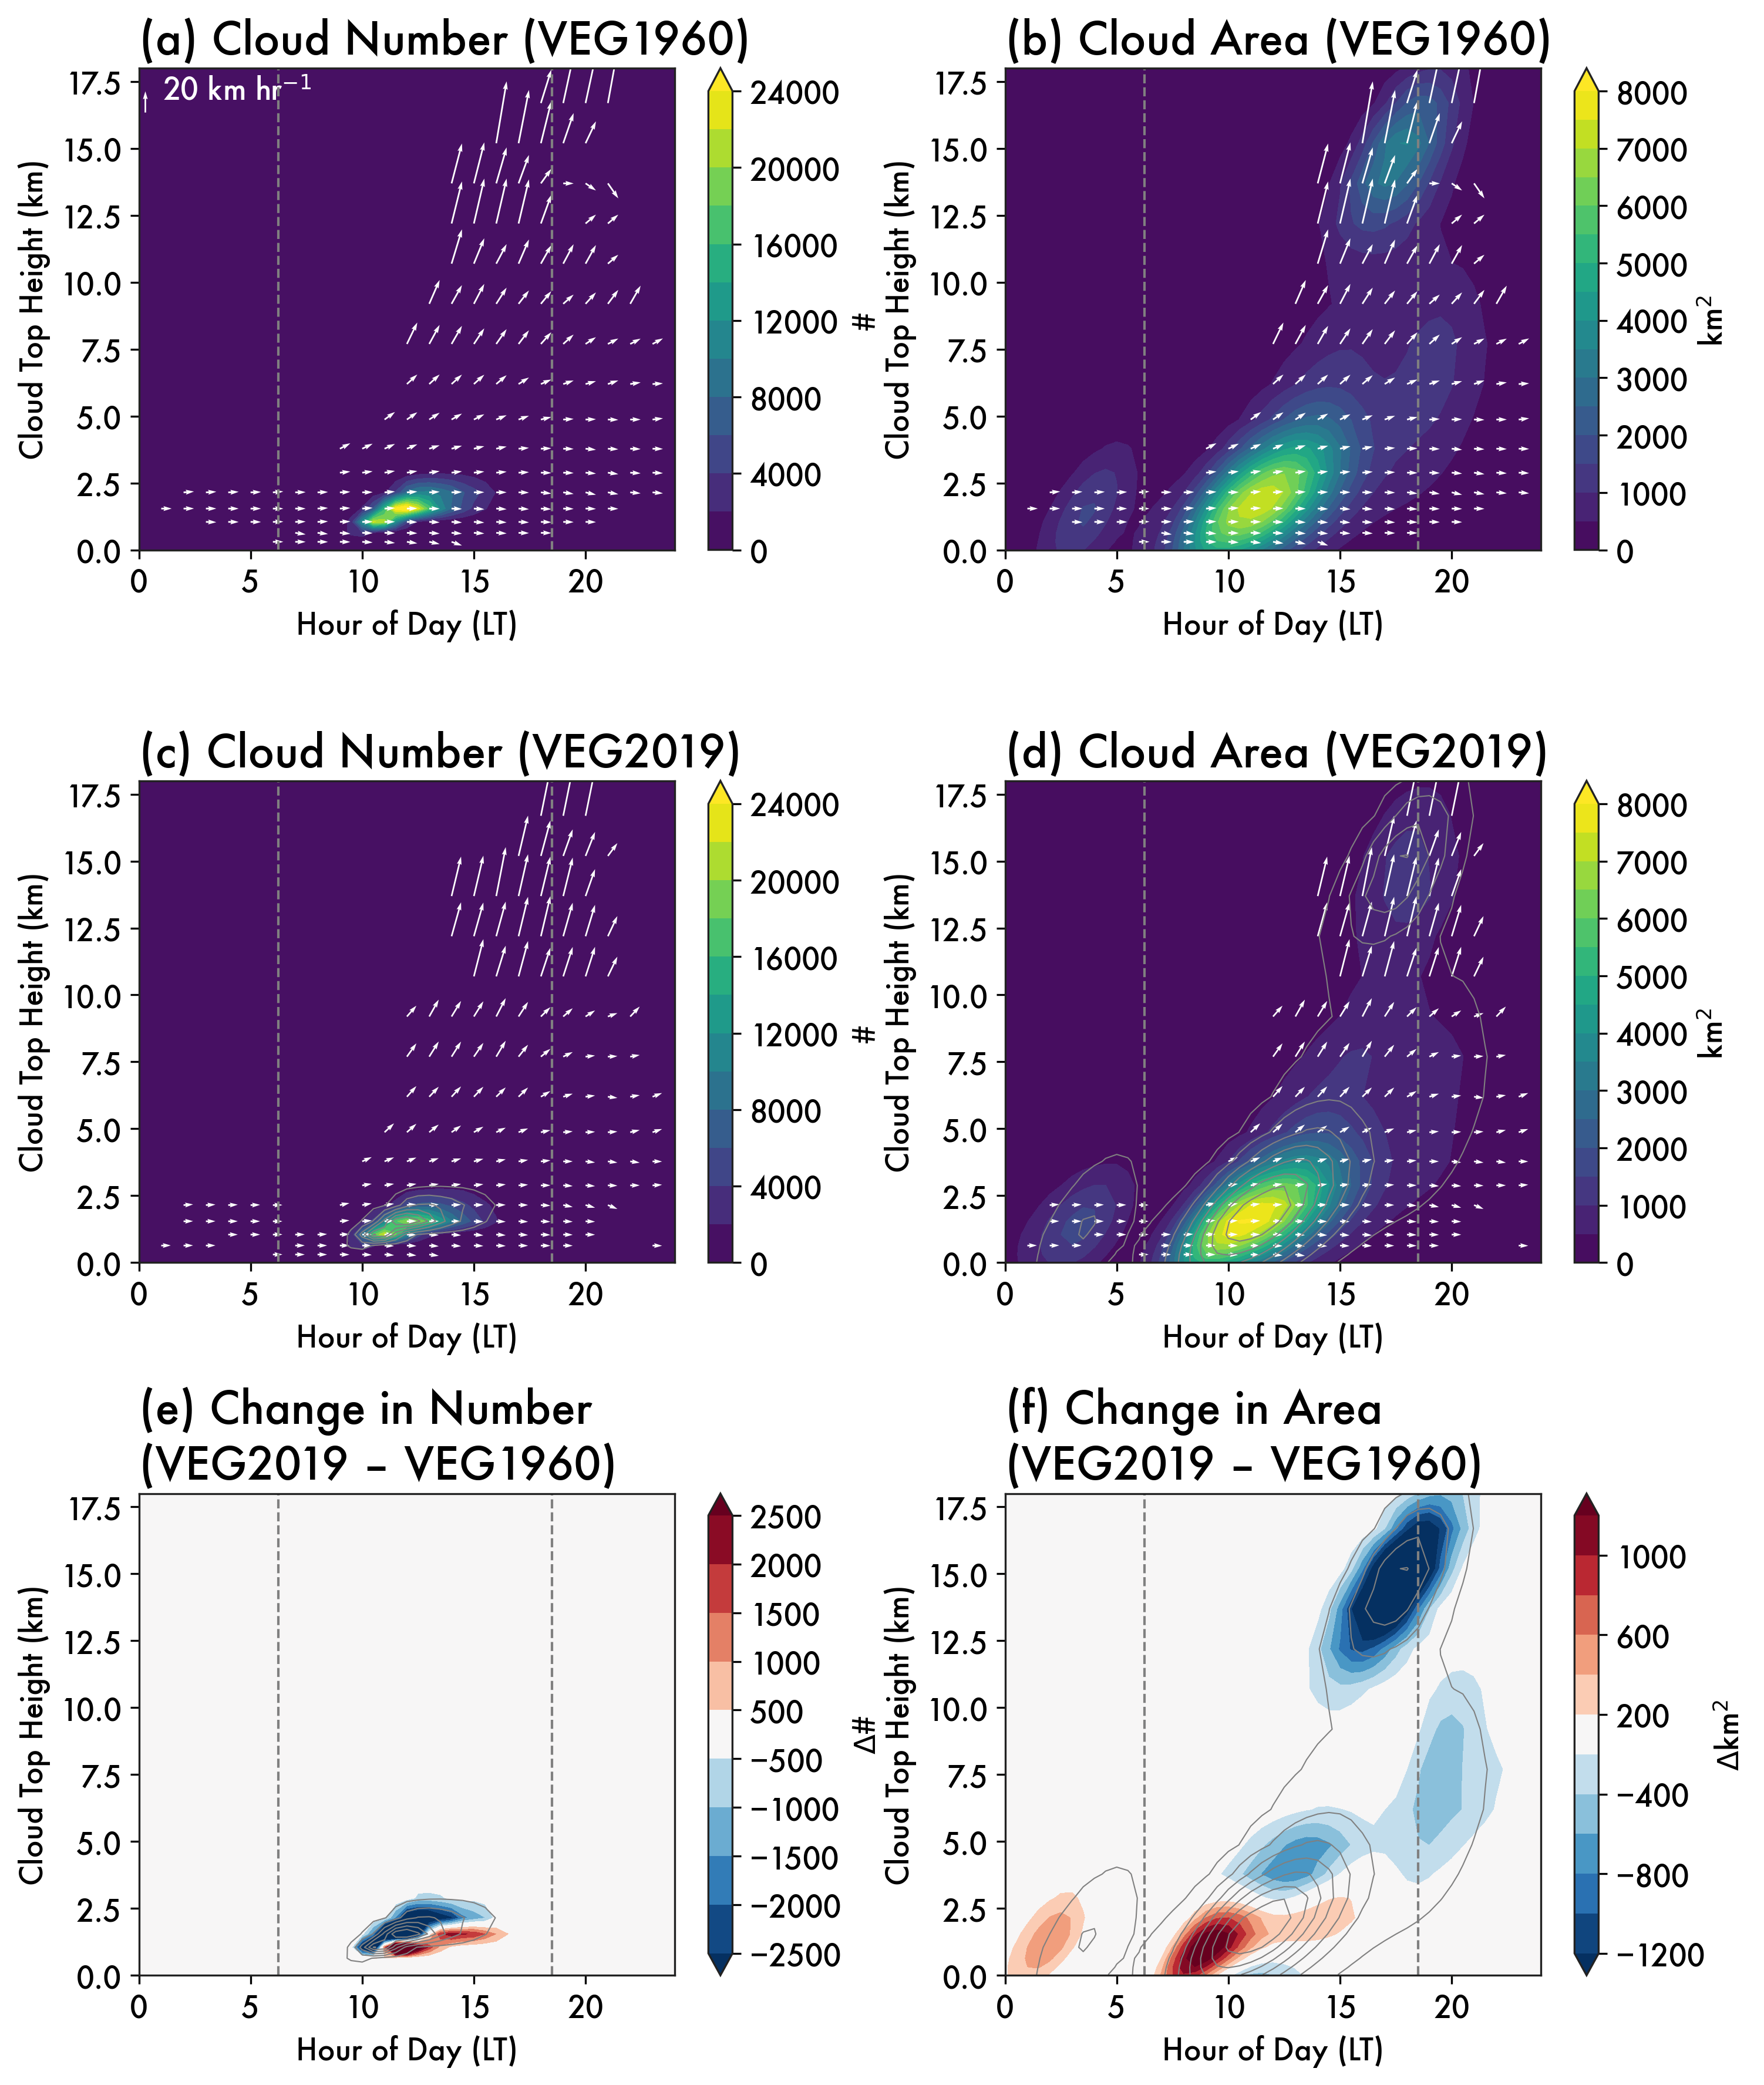

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

# plotting main filled contours
for ax, data, params in zip(
    axes.T.flatten(),
    [n_past, n_pres, n_pres - n_past, a_past, a_pres, a_pres - a_past],
    [n_mag, n_mag, n_diff, a_mag, a_mag, a_diff],
):

    c = ax.contourf(
        data.columns,
        data.index,
        data,
        cmap=params.get("cmap"),
        norm=params.get("norm"),
        levels=params.get("levels"),
        extend=params.get("extend"),
    )

    plt.colorbar(c, ax=ax, label=params.get("label"))


# plotting the number/area contours for VEG1960 simulation as reference on other panels
for axs, data, params in zip(
    [axes.T[0][1:], axes.T[1][1:]], [n_past, a_past], [n_mag, a_mag]
):
    for ax in axs:
        ax.contour(
            data.columns,
            data.index,
            data.values,
            colors="gray",
            levels=params.get("levels")[1::2],
            linewidths=0.5,
        )

# plotting mean cell trajectory
for axs, data in zip(axes[:2], [cells_past, cells_pres]):
    for ax in axs:
        traj = cell_traj(data)

        q = ax.quiver(
            traj.index,
            traj.columns,
            10 * np.ones(traj.T.shape),
            traj.T * 60 / 10,
            color="white",
        )

axes[0, 0].quiverkey(
    q,
    0.075,
    0.95,
    np.sqrt(10**2 + 20**2),
    r"20 km hr$^{-1}$",
    labelpos="E",
    coordinates="figure",
    color="white",
    labelcolor="white",
    angle=90,
)

# ancilliary plotting: figure labels, etc.
for ax, title in zip(
    axes.flatten(),
    [
        "(a) Cloud Number (VEG1960)",
        "(b) Cloud Area (VEG1960)",
        "(c) Cloud Number (VEG2019)",
        "(d) Cloud Area (VEG2019)",
        "(e) Change in Number\n(VEG2019 – VEG1960)",
        "(f) Change in Area\n(VEG2019 – VEG1960)",
    ],
):
    ax.set_title(title)
    ax.set_ylabel("Cloud Top Height (km)")
    ax.set_xlabel("Hour of Day (LT)")

    ax.axvline(6.25, ls="--", color="gray", lw=1)
    ax.axvline(18.5, ls="--", color="gray", lw=1)
    ax.set_ylim(0, 18)

plt.tight_layout()

# save figure
# plt.savefig(f"{figPath}/fig5_diurnal_clouds_6panel.pdf")
plt.show()
plt.close("all")

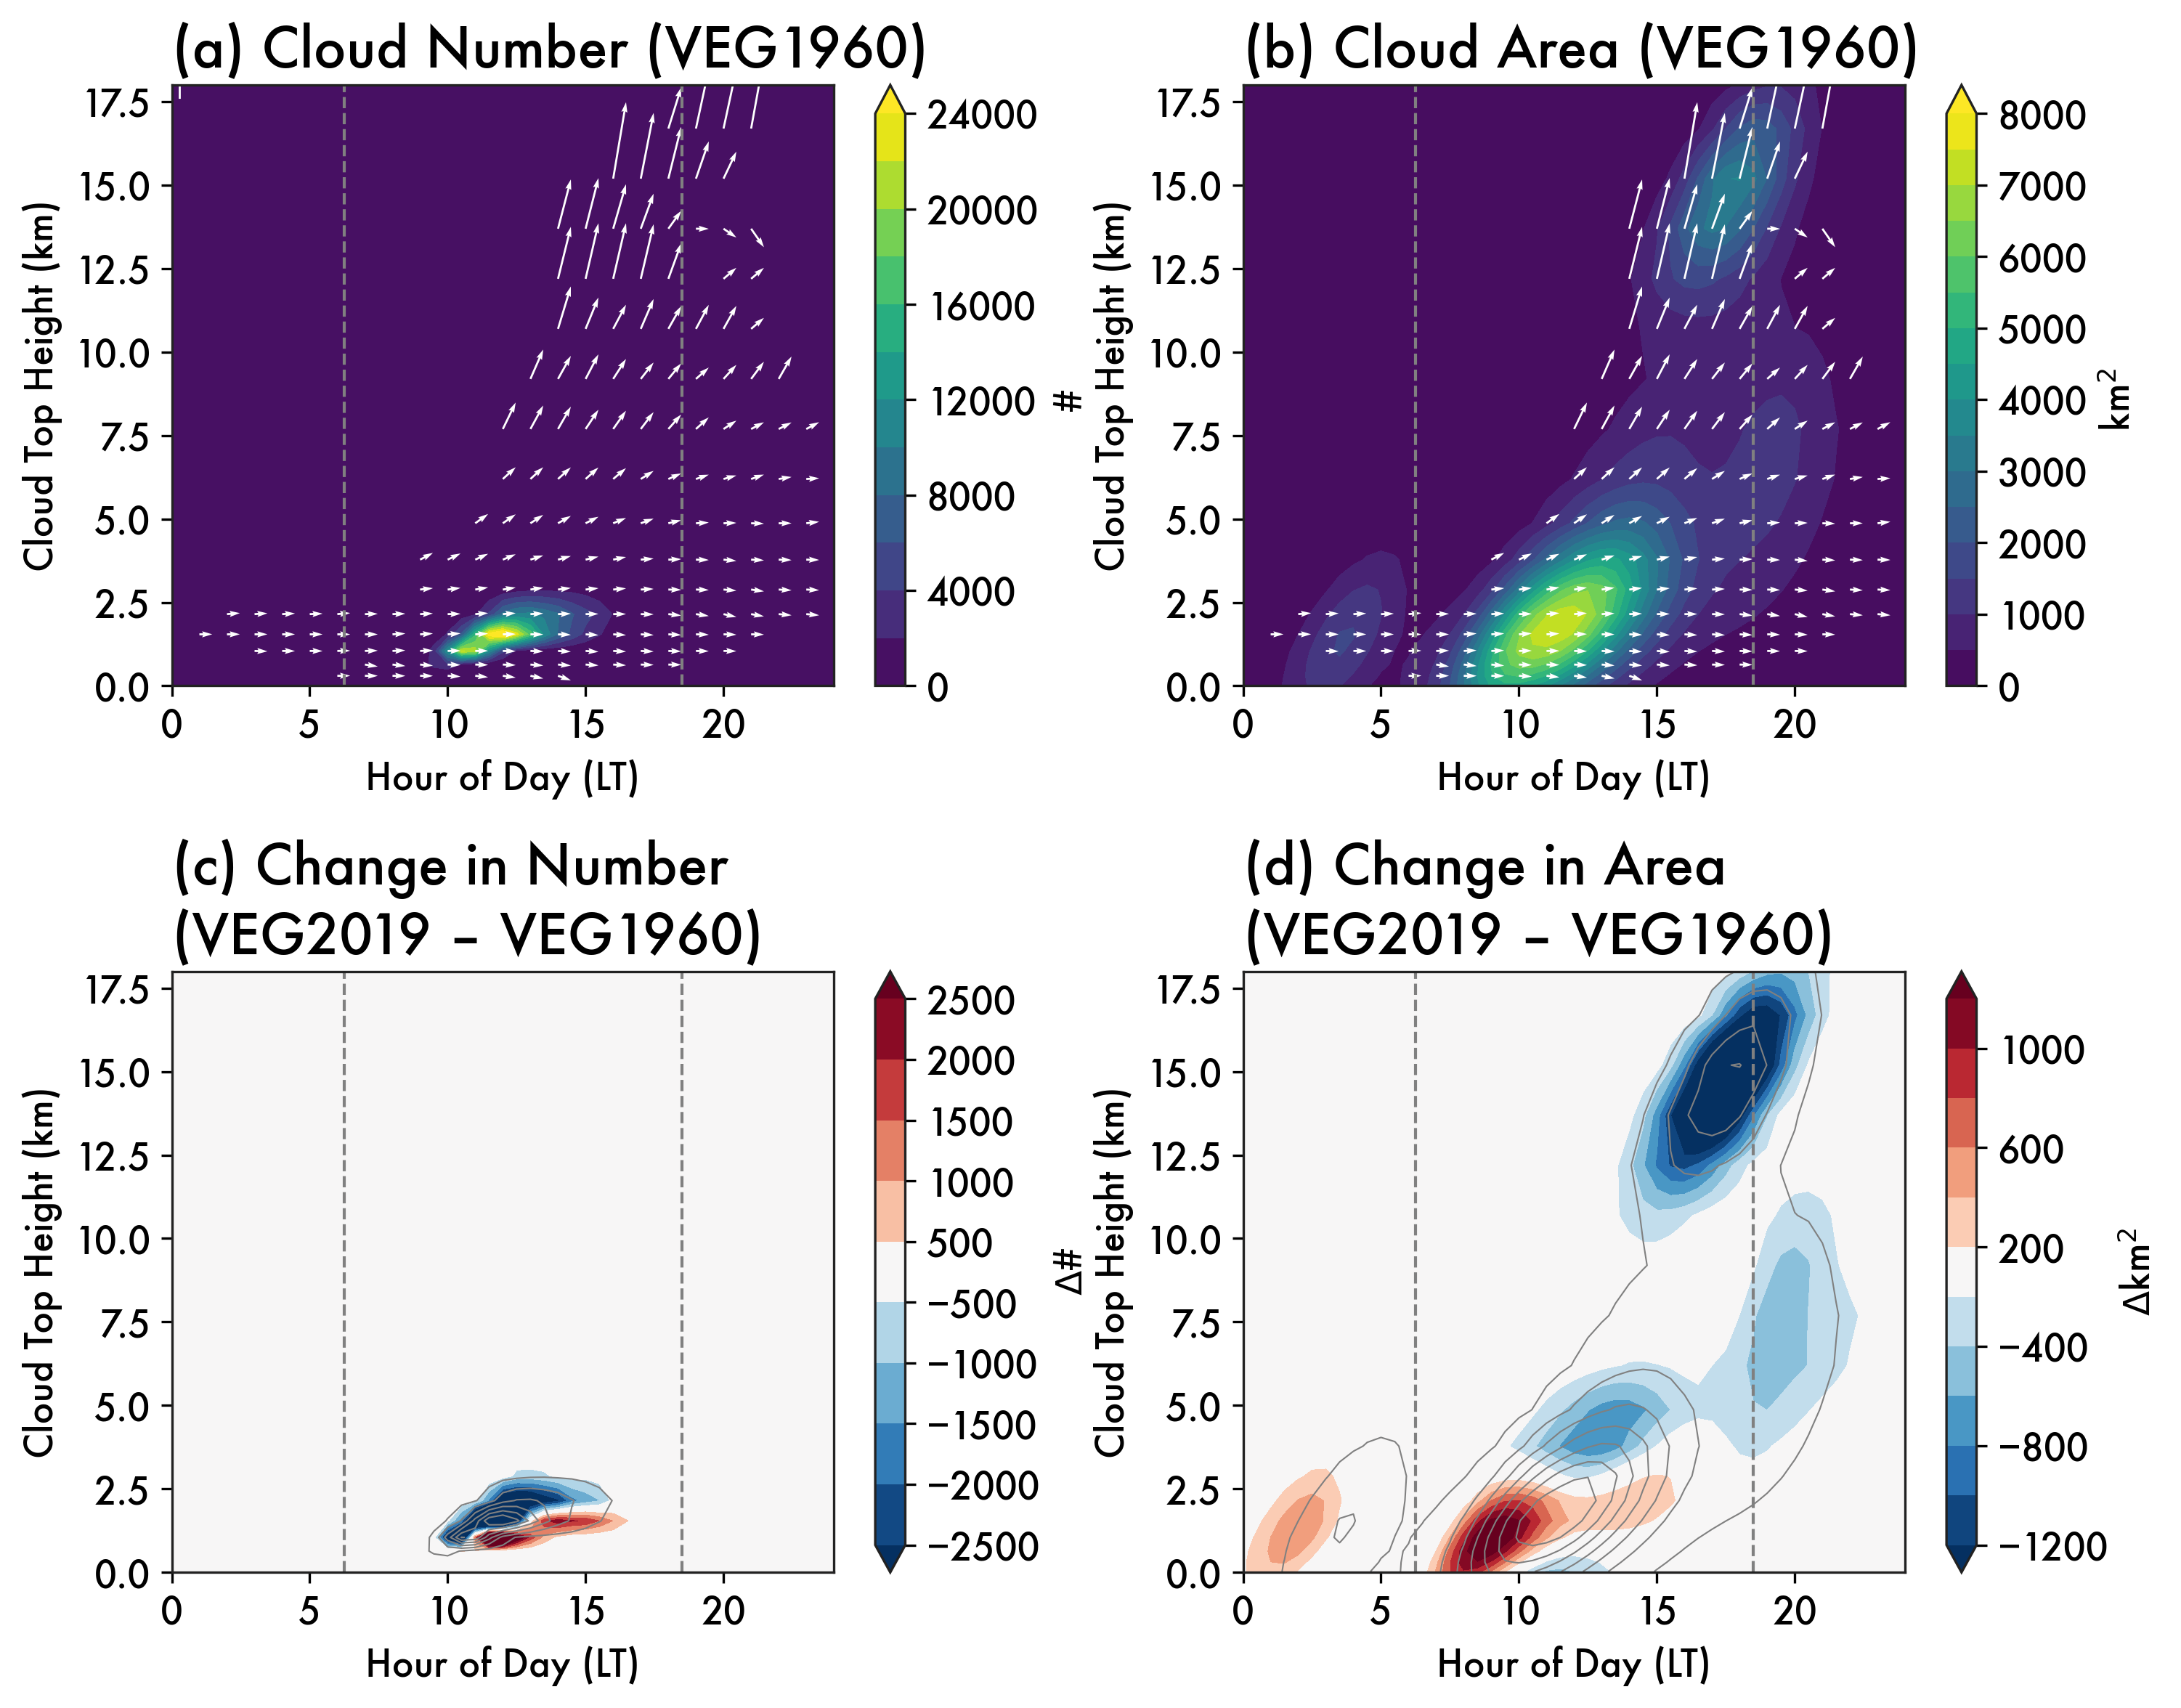

In [469]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# plotting main filled contours
for ax, data, params in zip(
    axes.T.flatten(),
    [n_past, n_pres - n_past, a_past, a_pres - a_past],
    [n_mag, n_diff, a_mag, a_diff],
):

    c = ax.contourf(
        data.columns,
        data.index,
        data,
        cmap=params.get("cmap"),
        norm=params.get("norm"),
        levels=params.get("levels"),
        extend=params.get("extend"),
    )

    plt.colorbar(c, ax=ax, label=params.get("label"))


# plotting the number/area contours for VEG1960 simulation as reference on other panels
for axs, data, params in zip(
    [axes.T[0][1:], axes.T[1][1:]], [n_past, a_past], [n_mag, a_mag]
):
    for ax in axs:
        ax.contour(
            data.columns,
            data.index,
            data.values,
            colors="gray",
            levels=params.get("levels")[1::2],
            linewidths=0.5,
        )

# plotting mean cell trajectory
for ax in axes[0]:
    traj = cell_traj(cells_past)

    q = ax.quiver(
        traj.index,
        traj.columns,
        10 * np.ones(traj.T.shape),
        traj.T * 60 / 10,
        color="white",
    )

axes[0, 0].quiverkey(
    q,
    0.075,
    0.95,
    np.sqrt(10**2 + 20**2),
    r"20 km hr$^{-1}$",
    labelpos="E",
    coordinates="figure",
    color="white",
    labelcolor="white",
    angle=90,
)

# ancilliary plotting: figure labels, etc.
for ax, title in zip(
    axes.flatten(),
    [
        "(a) Cloud Number (VEG1960)",
        "(b) Cloud Area (VEG1960)",
        "(c) Change in Number\n(VEG2019 – VEG1960)",
        "(d) Change in Area\n(VEG2019 – VEG1960)",
    ],
):
    ax.set_title(title)
    ax.set_ylabel("Cloud Top Height (km)")
    ax.set_xlabel("Hour of Day (LT)")

    ax.axvline(6.25, ls="--", color="gray", lw=1)
    ax.axvline(18.5, ls="--", color="gray", lw=1)
    ax.set_ylim(0, 18)

plt.tight_layout()

# save figure
plt.savefig(f"{figPath}/fig5_diurnal_clouds_4panel.pdf")
plt.show()
plt.close("all")

# Figure 6: LCL 

can calculate the LCL in vectorized way but not the LFC

In [ ]:
run = "lc1960"
t = 12
time_resolution = 0.5
# for given hour of the day, find RAMS paths within the time resolution we want
paths = find_paths_in_time_range(run, t, time_resolution)

In [ ]:
def run_thickness(pres_1, pres_2, t_1, t_2):
    height = mpcalc.thickness_hydrostatic(
        [pres_1, pres_2] * units.units("hPa"),
        [t_1, t_2] * units.units("celsius"),
    ).magnitude

    return height


run_thickness = np.vectorize(run_thickness)


def calculate_lcl_lfc(ds):
    ds = ds.sel(z=slice(1, 40), x=slice(500, 700), y=slice(500, 700))
    ds = ds.assign(
        {
            "T": (ds.THETA * (ds.PI / cp)) - 273.15,  # temperature in degC
            "PRES": (p00 * (ds.PI / cp) ** (cp / rd)) / 100,  # pressure in hPa
        }
    )

    ds = ds.assign(
        Td=(
            ("z", "y", "x"),
            mpcalc.dewpoint_from_specific_humidity(
                ds.PRES.values * units.units("hPa"),
                ds.T.values * units.units("celsius"),
                ds.RV.values * units.units("kg/kg"),
            ).magnitude,
        )
    )  # dewpoint in degC

    # lcl calculation
    x = mpcalc.lcl(
        ds.PRES.sel(z=0) * units.units("hPa"),
        ds.T.sel(z=0) * units.units("celsius"),
        ds.Td.sel(z=0) * units.units("celsius"),
    )
    ds = ds.assign(
        {
            "PRES_lcl": (("y", "x"), x[0].magnitude),
            "T_lcl": (("y", "x"), x[1].magnitude),
        }
    )

    ds = ds.assign(
        LCL_height=(
            ("y", "x"),
            run_thickness(ds.PRES.sel(z=0), ds.PRES_lcl, ds["T"].sel(z=0), ds.T_lcl),
        )
    )

    """ds = ds.assign(
        LFC_height=(
            ("y", "x"),
            xr.apply_ufunc(
                compute_lfc,
                ds.PRES.transpose("y", "x", "z"),
                ds["T"].transpose("y", "x", "z"),
                ds.Td.transpose("y", "x", "z"),
                input_core_dims=[["z"], ["z"], ["z"]],
                output_core_dims=[],
                exclude_dims=set(("z")),
                vectorize=True,
                # output_dtypes=[ds.LCL_height.dtype],
                dask="parallelized",
                # output_dtypes="float64",,
            ),
        )
    )

    compute_lfc(
        ds.PRES.transpose("y", "x", "z"),
        ds["T"].transpose("y", "x", "z"),
        ds.Td.transpose("y", "x", "z"),
    ),"""

    return ds[["LCL_height", "PRES", "T", "Td"]]  # "LFC_height"]]

In [ ]:
def compute_lfc(p, t, td):
    lfc_p, lfc_t = mpcalc.lfc(
        [p] * units.units("hPa"),
        [t] * units.units("celsius"),
        [td] * units.units("celsius"),
    )

    height = run_thickness(
        p[0] * units.units("hPa"), lfc_p, t[0] * units.units("celsius"), lfc_t
    )

    return height


compute_lfc = np.vectorize(compute_lfc, signature="(z),(z),(z)->()")


def calculate_lfc(ds):
    ds = ds.transpose("y", "x", "z")
    ds = ds.assign(LFC_height=(("y", "x"), compute_lfc(ds["PRES"], ds["T"], ds["Td"])))
    return ds[["LCL_height", "LFC_height"]]

In [ ]:
# read rams output
ds = client.map(
    get_rams_output,
    paths[:1],
    variables=["PI", "THETA", "RV"],
)

ds = client.map(remove_boundaries, ds)

# data = client.gather(ds)[0].sel(x=slice(500, 520), y=slice(500, 520))

ds = client.map(calculate_lcl_lfc, ds)
ds = client.map(calculate_lfc, ds)
# compute mean over land points
"""ds = client.map(
    get_land_mean,
    ds,
    landmask=landmask.sel(x=slice(500, 1000), y=slice(500, 1000)),
)"""

In [ ]:
ds = client.gather(ds)

In [ ]:
out  # 200x200 takes 5.5 mins to run with batch_size default; 5min 20s with batch_size=2; 5min7s with batch_size=12)

In [ ]:
data = data.transpose("y", "x", "z")

In [ ]:
out = compute_lfc(
    data["PRES"],
    data["T"],
    data["Td"],
)

In [ ]:
out = xr.apply_ufunc(
    compute_lfc,
    data["PRES"],
    data["T"],
    data["Td"],
    dask="allowed",
    input_core_dims=[["z"], ["z"], ["z"]],
    output_core_dims=[],
    vectorize=True,
)

In [ ]:
ds = ds.assign(
    LFC_height=(
        ("y", "x"),
        xr.apply_ufunc(
            compute_lfc,
            ds.PRES.transpose("y", "x", "z"),
            ds["T"].transpose("y", "x", "z"),
            ds.Td.transpose("y", "x", "z"),
            input_core_dims=[["z"], ["z"], ["z"]],
            output_core_dims=[],
            exclude_dims=set(("z")),
            vectorize=True,
            # output_dtypes=[ds.LCL_height.dtype],
            dask="parallelized",
            # output_dtypes="float64",,
        ),
    )
)

In [ ]:
ds = ds[0]  # xr.concat(ds, dim="t")

In [ ]:
ds = ds.compute()

In [ ]:
ds

In [ ]:
ds = ds[["LCL_height", "LFC_height"]]

In [ ]:
plt.pcolormesh(ds.LFC_height)

# Figure 7: Spatial heterogeneity in cloud response

See Figure 5 description for tobac procedure. THis uses the same QC final output.

## Read in tobac

In [478]:
cells_past = pd.read_parquet(
    f"/squall/gleung/borneolcc-analysis/tobac/lc1960_rte/qc_final_cloudy_updrafts.pq"
)
cells_pres = pd.read_parquet(
    f"/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/qc_final_cloudy_updrafts.pq"
)

In [479]:
def get_diurnal_peak(
    cells: pd.DataFrame, spaceres=7, timeres=0.25, var="feature", agg="count"
) -> xr.DataArray:
    """
    Takes in tobac output dataframe list of cloudy updraft and calculates a mean diurnal cycle for each grid point.

    Arguments:
        cells -- tobac output dataframe
        return_peak (bool) -- whether to just return the diurnal peak or full array

    Returns:
        DataArray of the number of features along (y, x, hour_day) space
    """

    out = cells.groupby(
        [
            pd.cut(
                cells.y - 50,
                np.arange(0, 2130 + spaceres, spaceres),
                labels=np.arange(0, 2130 + spaceres, spaceres)[:-1],
            ),
            pd.cut(
                cells.x - 50,
                np.arange(0, 2050 + spaceres, spaceres),
                labels=np.arange(0, 2050 + spaceres, spaceres)[:-1],
            ),
            pd.cut(
                cells.hour_day,
                np.arange(0, 24, timeres),
                labels=np.arange(0, 24, timeres)[:-1],
            ),
        ],
        observed=False,
    )[var].agg(agg) * (1 // timeres)

    out = out.to_xarray()

    return out

In [ ]:
# These parameters correspond to binning along 1x1km boxes then smoothing rolling mean over 10x10km boxes
coarseres = 40
print(coarseres * 150 / 1000)
rollres = 5

lats = smooth_data_plotting(remove_boundaries(topo.GLAT), coarseres, rollres).compute()
lons = smooth_data_plotting(remove_boundaries(topo.GLON), coarseres, rollres).compute()
land = smooth_data_plotting(landmask, coarseres, rollres).compute()
forest = (
    smooth_data_plotting(forest_loss, coarseres, rollres).where(land > 0.5).compute()
)

6.0


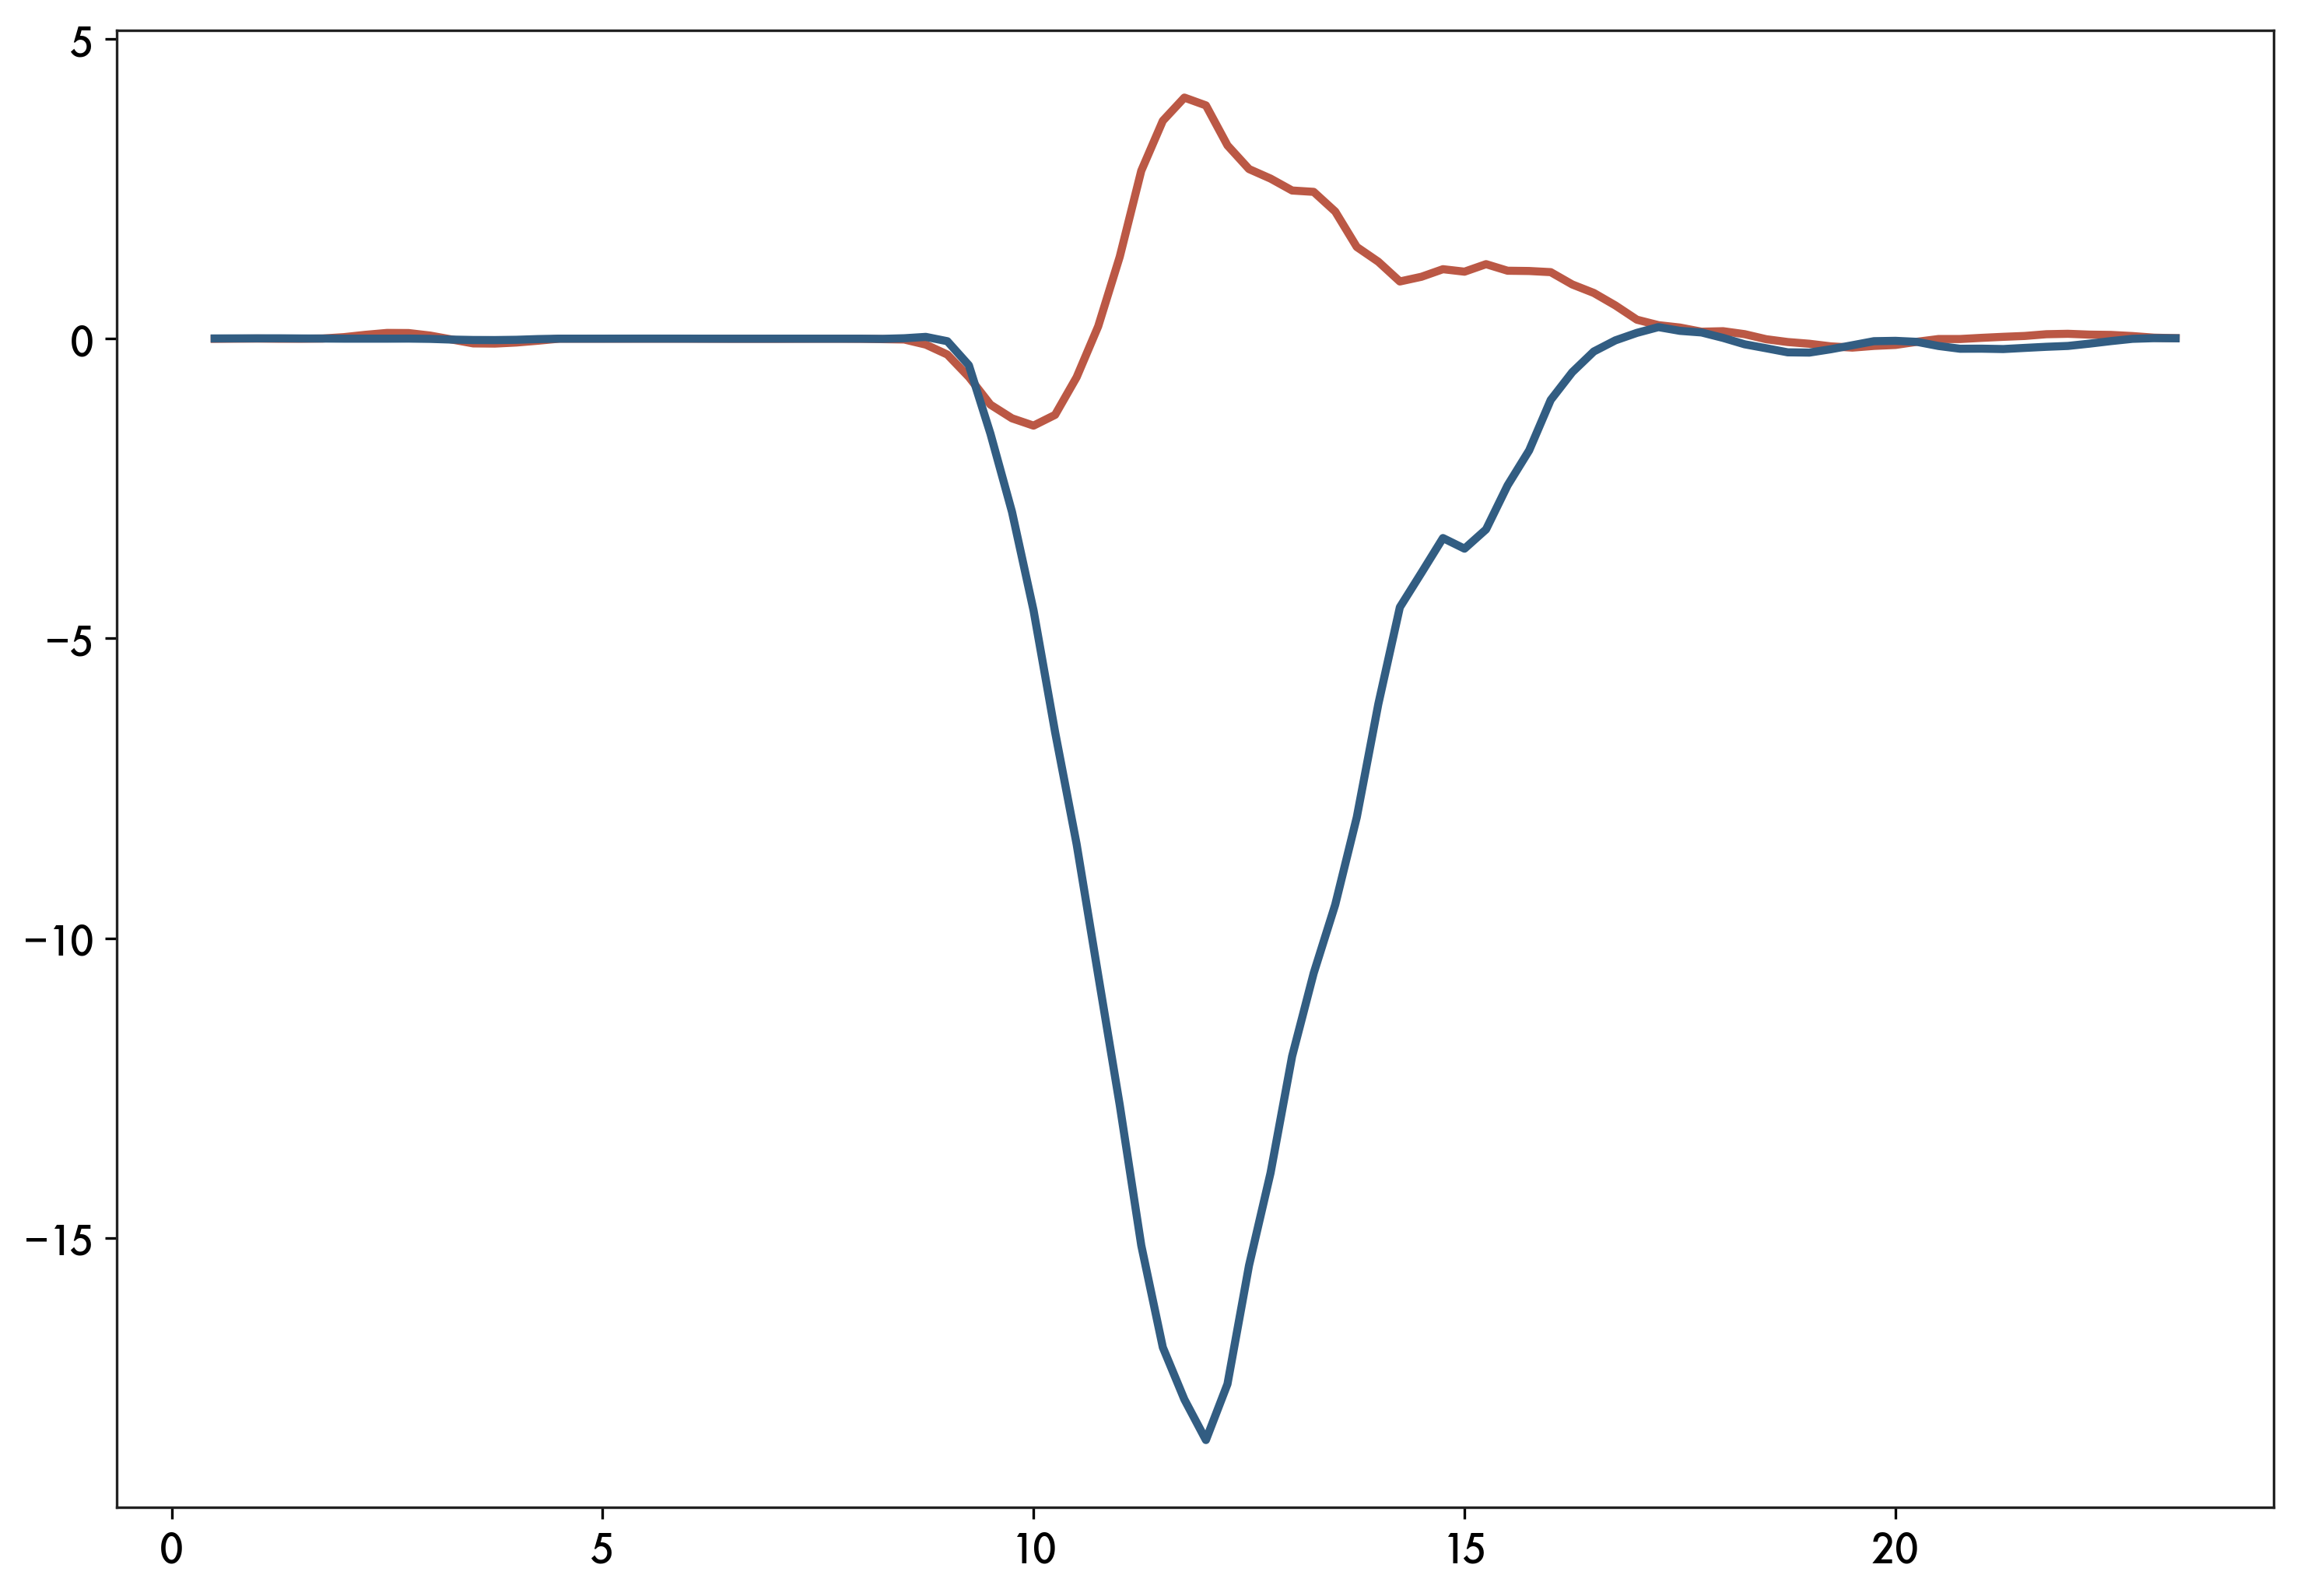

In [481]:
diurn_past = get_diurnal_peak(cells_past, spaceres=coarseres)
diurn_past = smooth_data_plotting(diurn_past, 1, rollres, coarseagg="sum")

diurn_pres = get_diurnal_peak(cells_pres, spaceres=coarseres)
diurn_pres = smooth_data_plotting(diurn_pres, 1, rollres, coarseagg="sum")

diurn_diff = diurn_pres - diurn_past

peak_past = diurn_past.max(dim="hour_day")
peak_pres = diurn_pres.max(dim="hour_day")

peak_diff = peak_pres - peak_past

bot_pts = peak_diff <= np.quantile(peak_diff, 0.1)
bot = (
    diurn_diff.where(bot_pts)
    .mean(dim=("x", "y"))
    .rolling(hour_day=4, center=True)
    .mean()
)

top_pts = peak_diff >= np.quantile(peak_diff, 0.9)
top = (
    diurn_diff.where(top_pts)
    .mean(dim=("x", "y"))
    .rolling(hour_day=4, center=True)
    .mean()
)

plt.plot(top.hour_day, top)
plt.plot(bot.hour_day, bot)

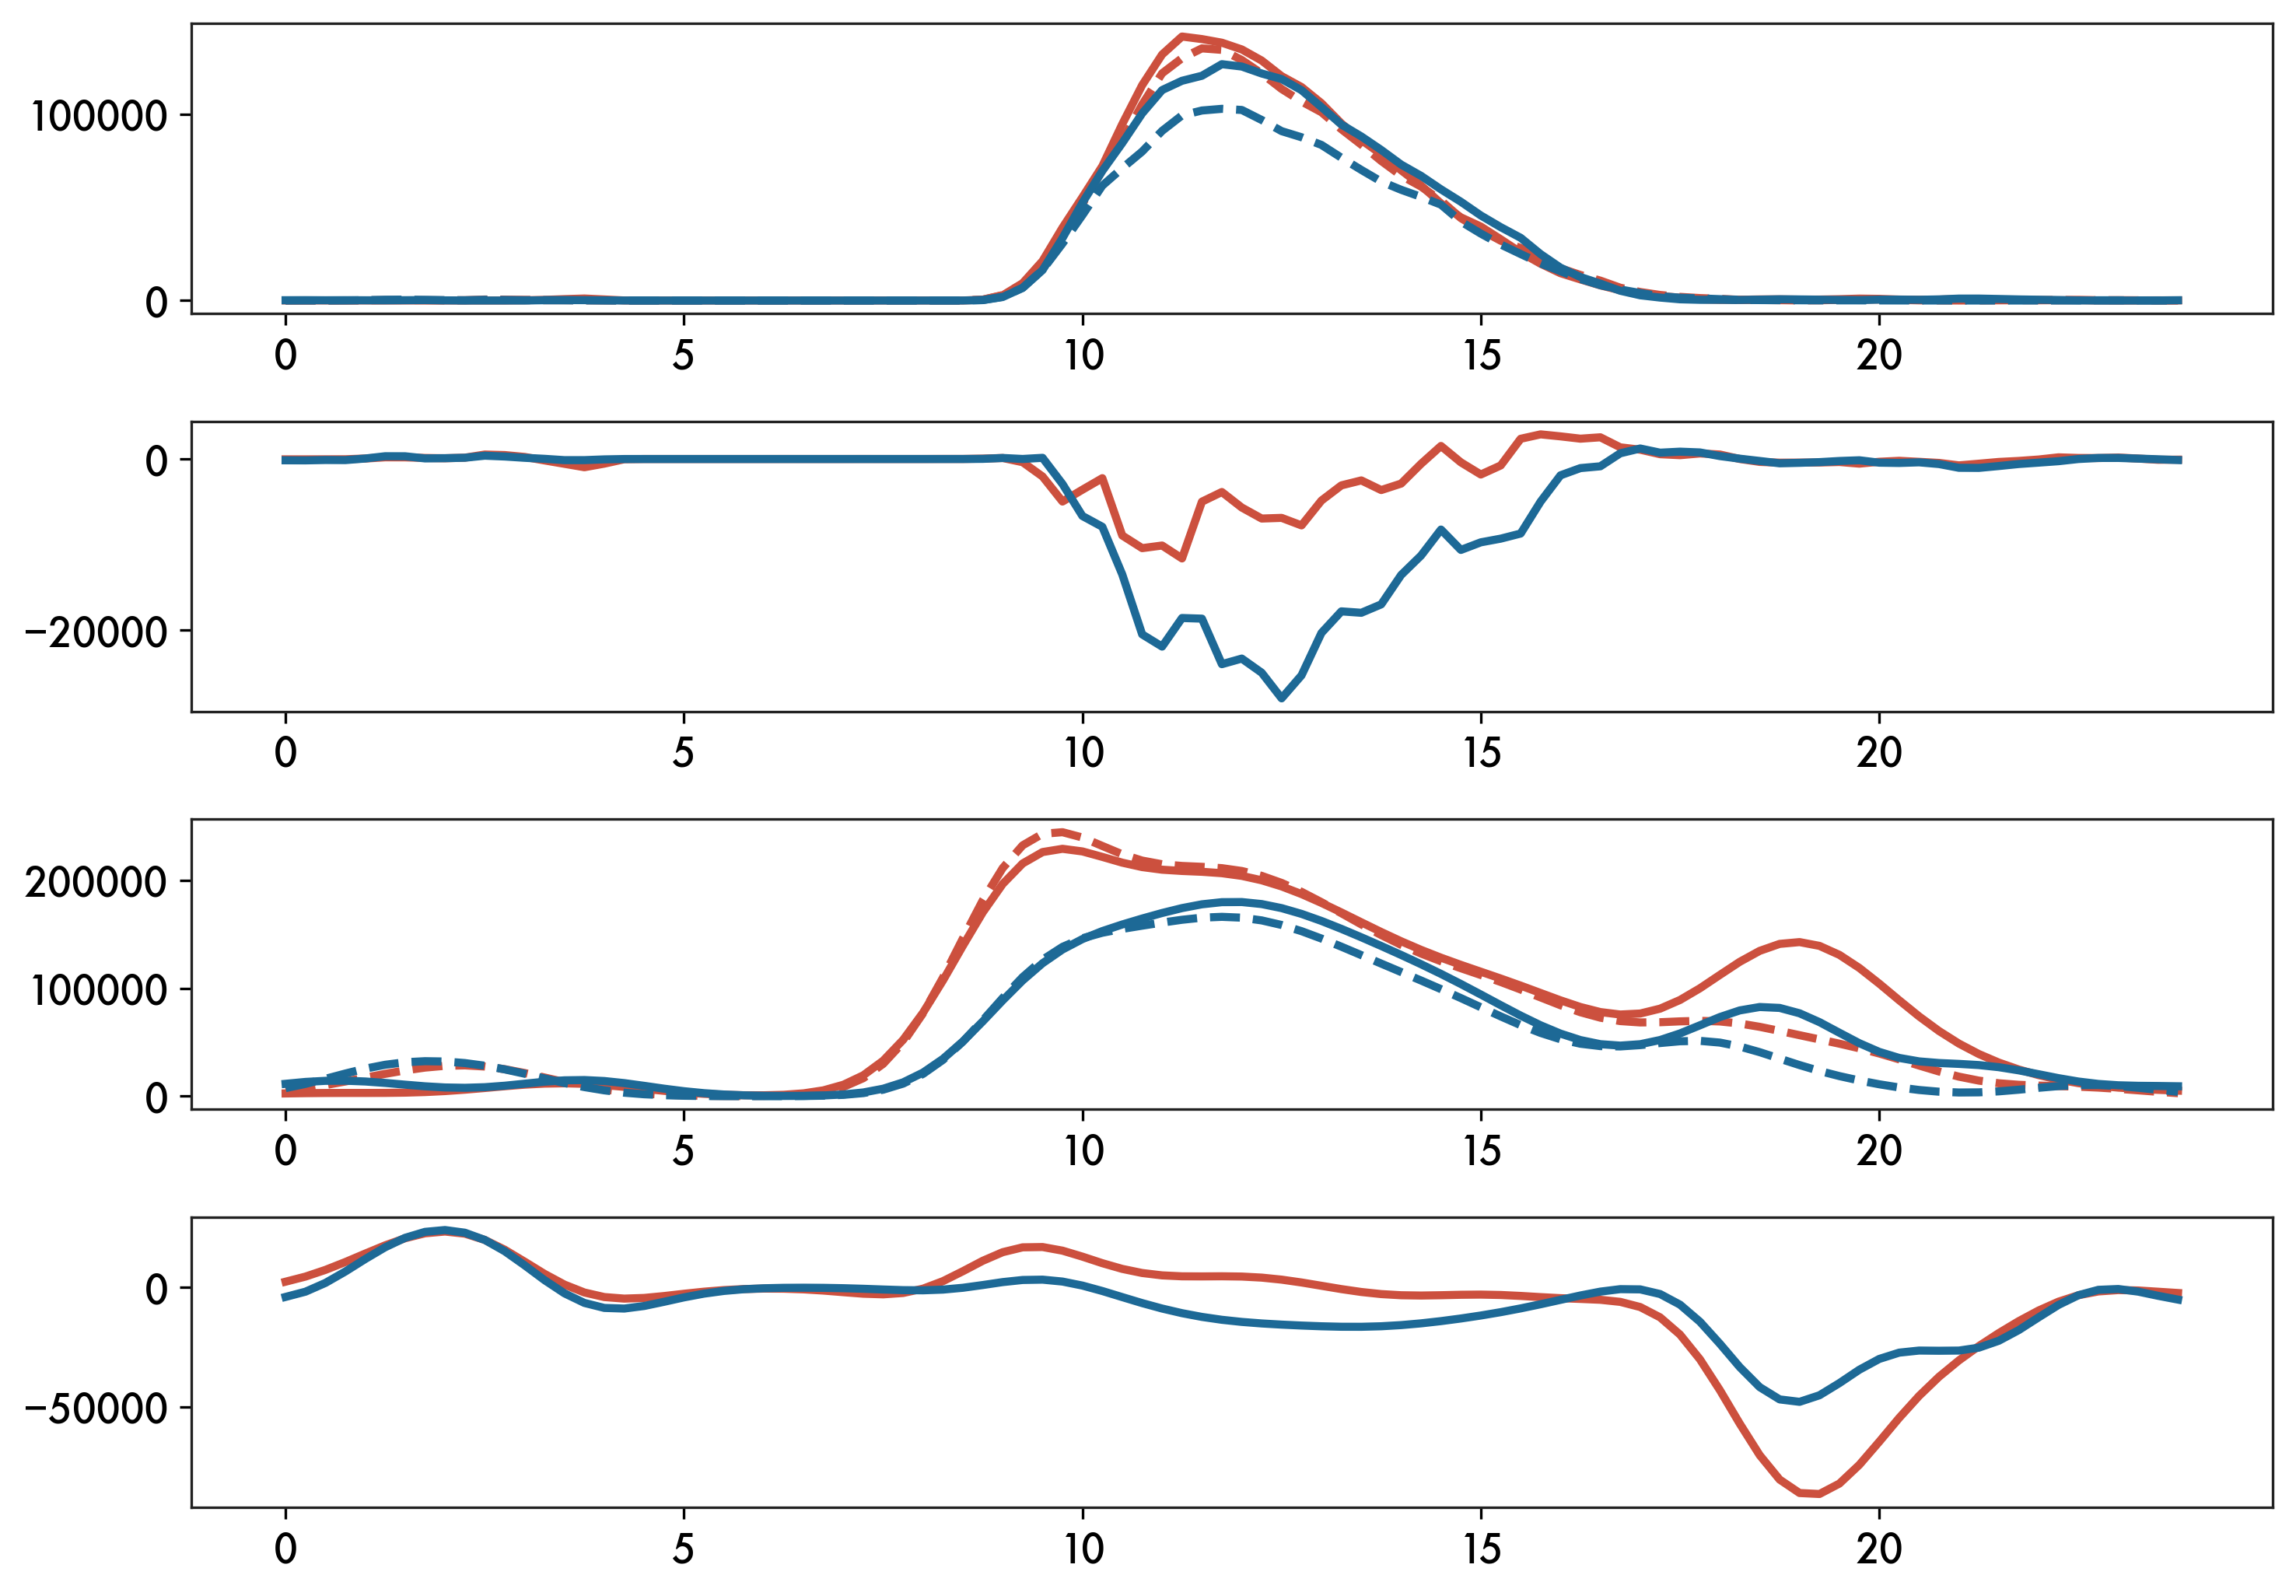

In [ ]:
fig, axes = plt.subplots(4, 1)

for pts, color in zip([top_pts, bot_pts], [red, blue]):
    x = pts.to_dataframe()
    x = x[x].dropna()

    past = []
    pres = []

    for i in x.index.values:
        past.append(
            cells_past[
                (cells_past.y >= i[0])
                & (cells_past.y < i[1] + coarseres)
                & (cells_past.x >= i[1])
                & (cells_past.x < i[1] + coarseres)
            ]
        )

        pres.append(
            cells_pres[
                (cells_pres.y >= i[0])
                & (cells_pres.y < i[1] + coarseres)
                & (cells_pres.x >= i[1])
                & (cells_pres.x < i[1] + coarseres)
            ]
        )

    past = pd.concat(past)
    pres = pd.concat(pres)

    X = np.arange(0, 24, 0.25)
    kde = gaussian_kde(
        past["hour_day"],
    )
    axes[0].plot(X, kde(X) * len(past), color=color)

    kde2 = gaussian_kde(
        pres["hour_day"],
    )

    axes[0].plot(X, kde2(X) * len(pres), ls="--", color=color)

    axes[1].plot(X, (kde2(X) * len(pres)) - (kde(X) * len(past)), color=color)

    kde = gaussian_kde(
        past["hour_day"],
        weights=past.cond_footprint.fillna(0) / past.cond_footprint.sum(),
    )
    axes[2].plot(X, kde(X) * past.cond_footprint.sum(), color=color)

    kde2 = gaussian_kde(
        pres["hour_day"],
        weights=pres.cond_footprint.fillna(0) / pres.cond_footprint.sum(),
    )

    axes[2].plot(X, kde2(X) * pres.cond_footprint.sum(), ls="--", color=color)

    axes[3].plot(
        X,
        (kde2(X) * pres.cond_footprint.sum()) - (kde(X) * past.cond_footprint.sum()),
        color=color,
    )

plt.show()

(-0.016695521771907806, 2.730254650115967)

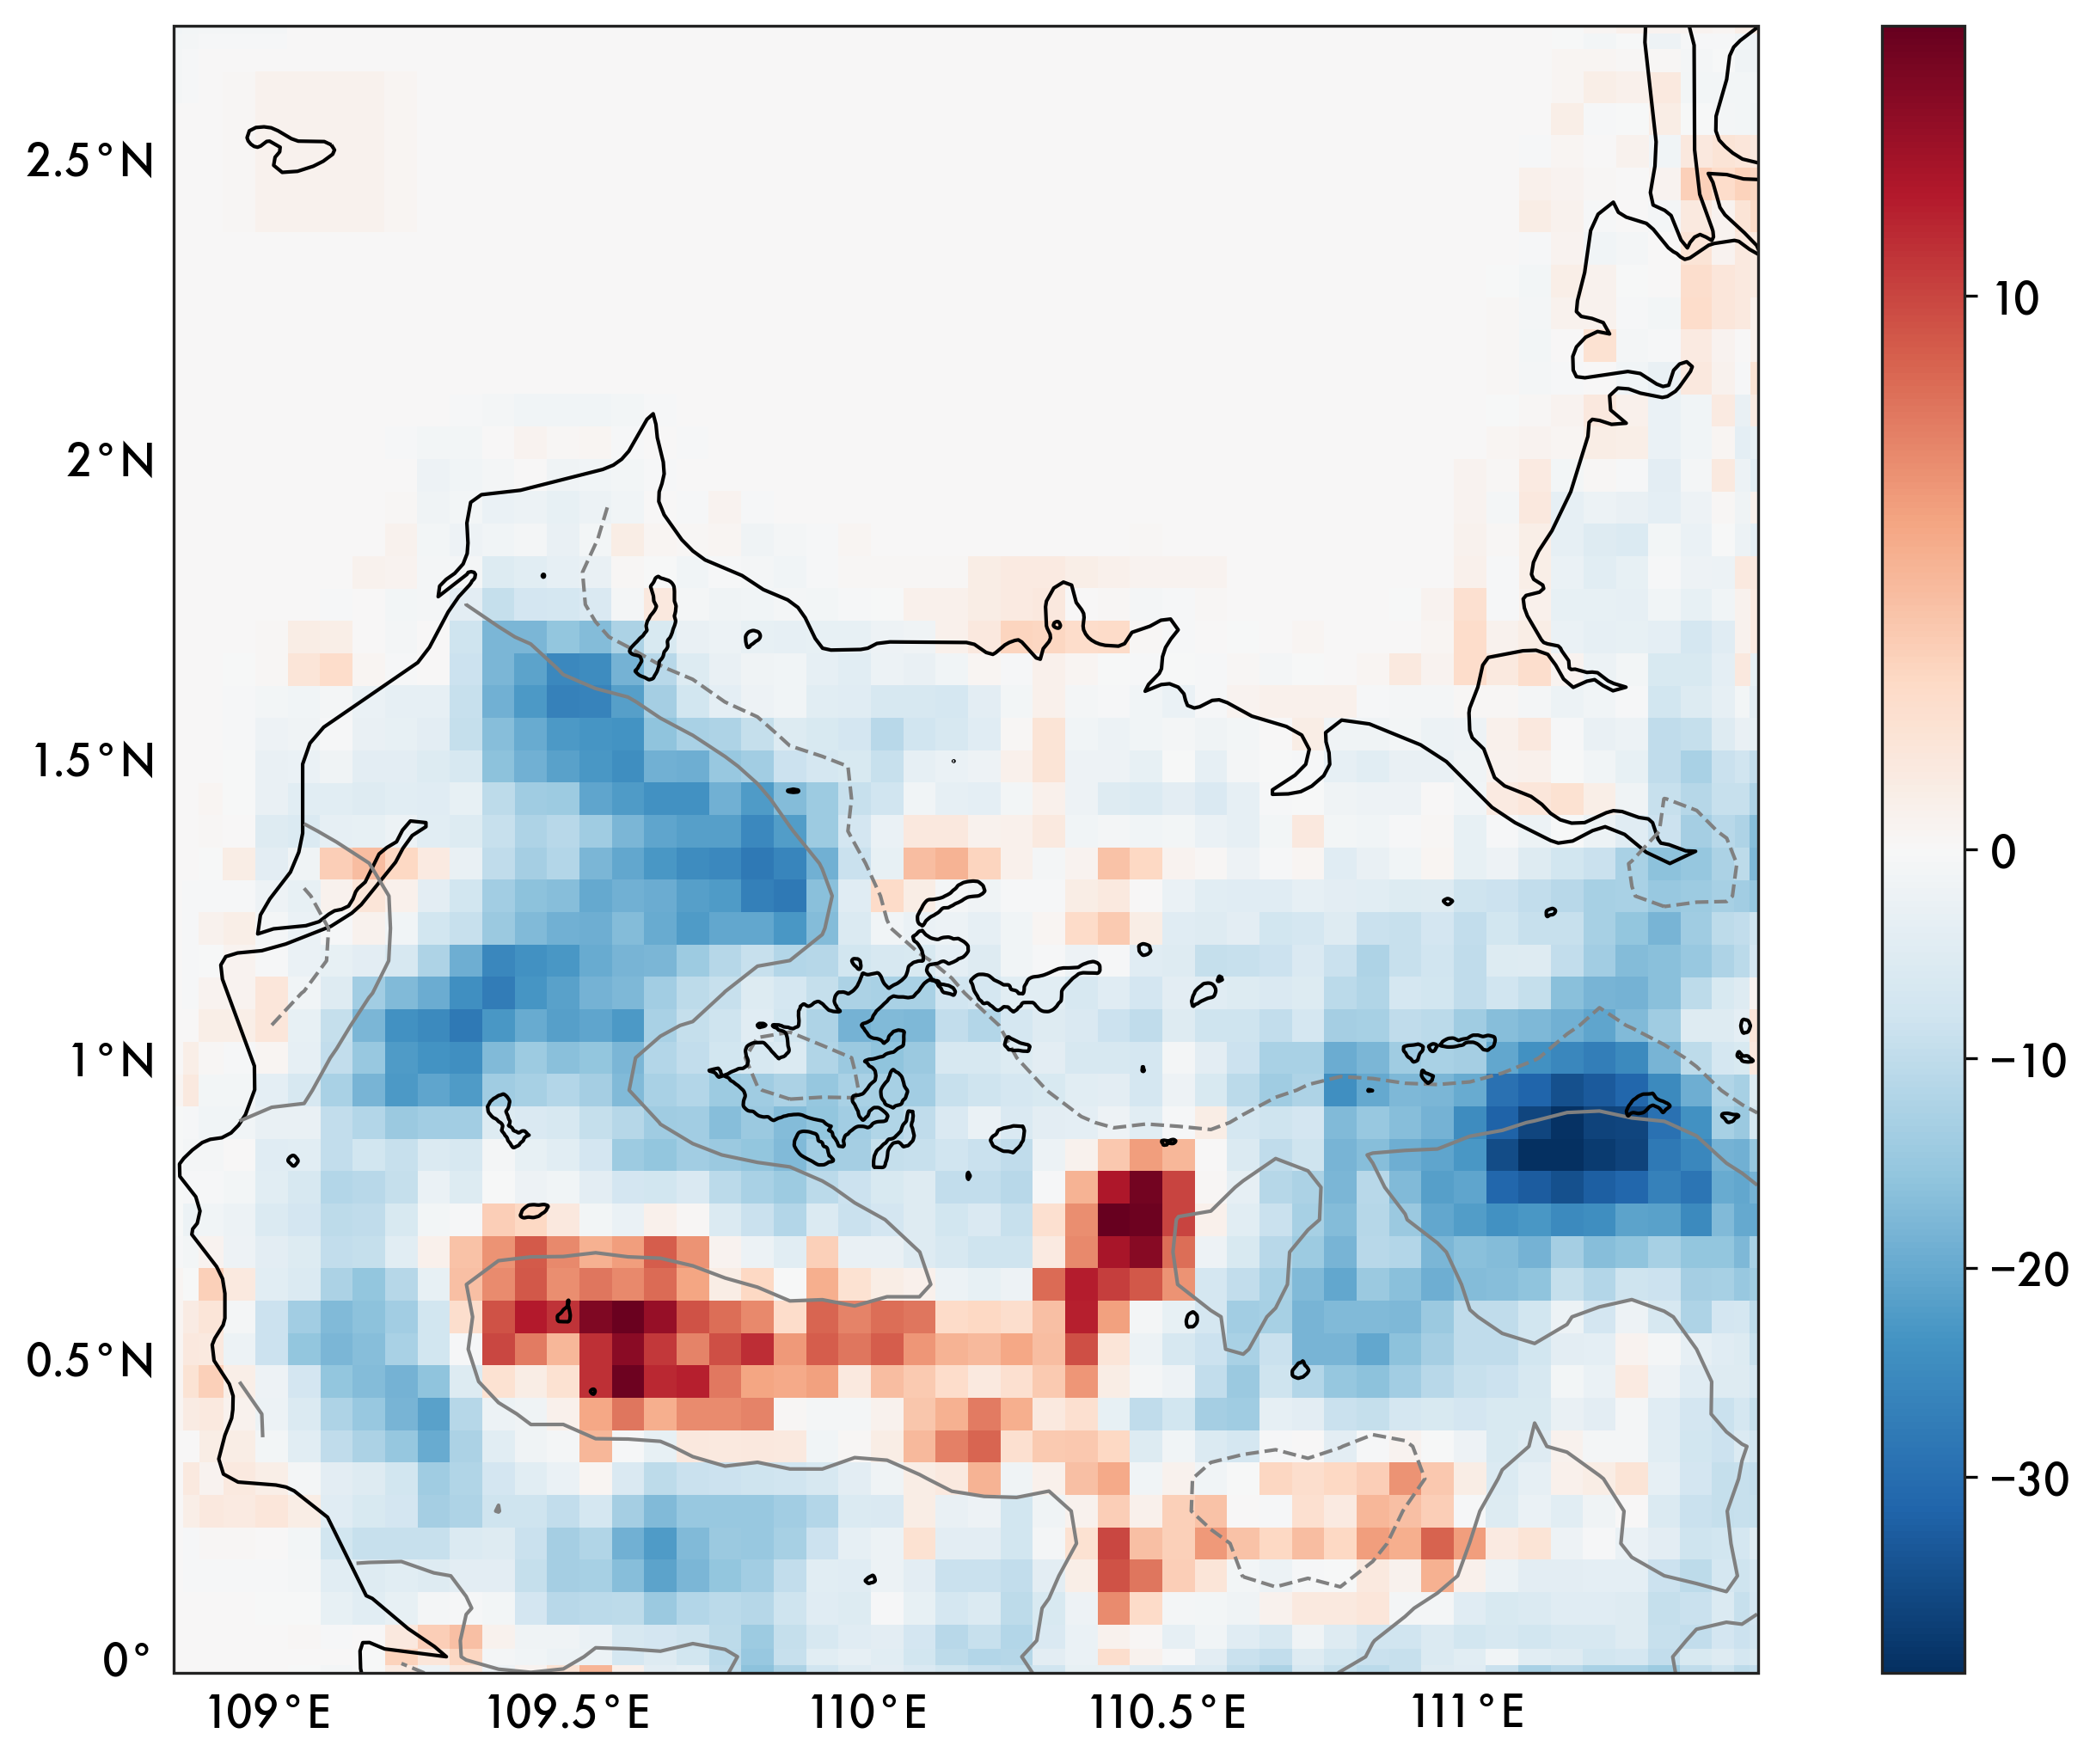

In [483]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot = peak_pres - peak_past
c = ax.pcolormesh(
    lons,
    lats,
    plot.values,
    cmap="RdBu_r",
    norm=mcolors.TwoSlopeNorm(vcenter=0),
)
plt.colorbar(c, ax=ax)

ax.contour(
    lons,
    lats,
    forest,
    levels=[-0.5, -0.25],
    colors=["gray", "gray"],
    linestyles=["-", "--"],
    linewidths=[1, 1],
)

ax.coastlines()
add_latlon(ax)
add_topography(ax, topo, lcol="black")

ax.set_xlim(lons.min(), lons.max())
ax.set_ylim(lats.min(), lats.max())

# Figure 8: Mesoscale circulations

This script uses output from "calculate_diurnal_maps.py", but then smooths data for easier visualization.

## Read in output and take difference of VEG2019-VEG1960

In [138]:
diff = (
    xr.open_dataset(
        f"/squall/gleung/borneolcc-analysis/paper-analysis/maps-diurnal-lc2019.h5"
    )
    - xr.open_dataset(
        f"/squall/gleung/borneolcc-analysis/paper-analysis/maps-diurnal-lc1960.h5"
    )
).sel(hour_day=10)

## Set some smoothing parameters

This aggregates data to ~1km, then takes a rolling mean over 10km.

In [ ]:
coarseres = 20
rollres = 5

lats = smooth_data_plotting(remove_boundaries(topo.GLAT), coarseres, rollres).compute()
lons = smooth_data_plotting(remove_boundaries(topo.GLON), coarseres, rollres).compute()
land = smooth_data_plotting(landmask, coarseres, rollres).compute()
forest = (
    smooth_data_plotting(forest_loss, coarseres, rollres).where(land > 0.5).compute()
)

## Actual Plot

<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1406094/3665366421.py:19: SyntaxWarning: invalid escape sequence '\ '
  "(c) $\\theta_{v,\ surf}$",
/tmp/ipykernel_1406094/3665366421.py:20: SyntaxWarning: invalid escape sequence '\ '
  "(d) Pert. $\\theta_{v,\ surf}$",
/tmp/ipykernel_1406094/3665366421.py:34: SyntaxWarning: invalid escape sequence '\D'
  label = "$\Delta$ W m$^{-2}$"
/tmp/ipykernel_1406094/3665366421.py:38: SyntaxWarning: invalid escape sequence '\D'
  label = "$\Delta ^\circ$C"


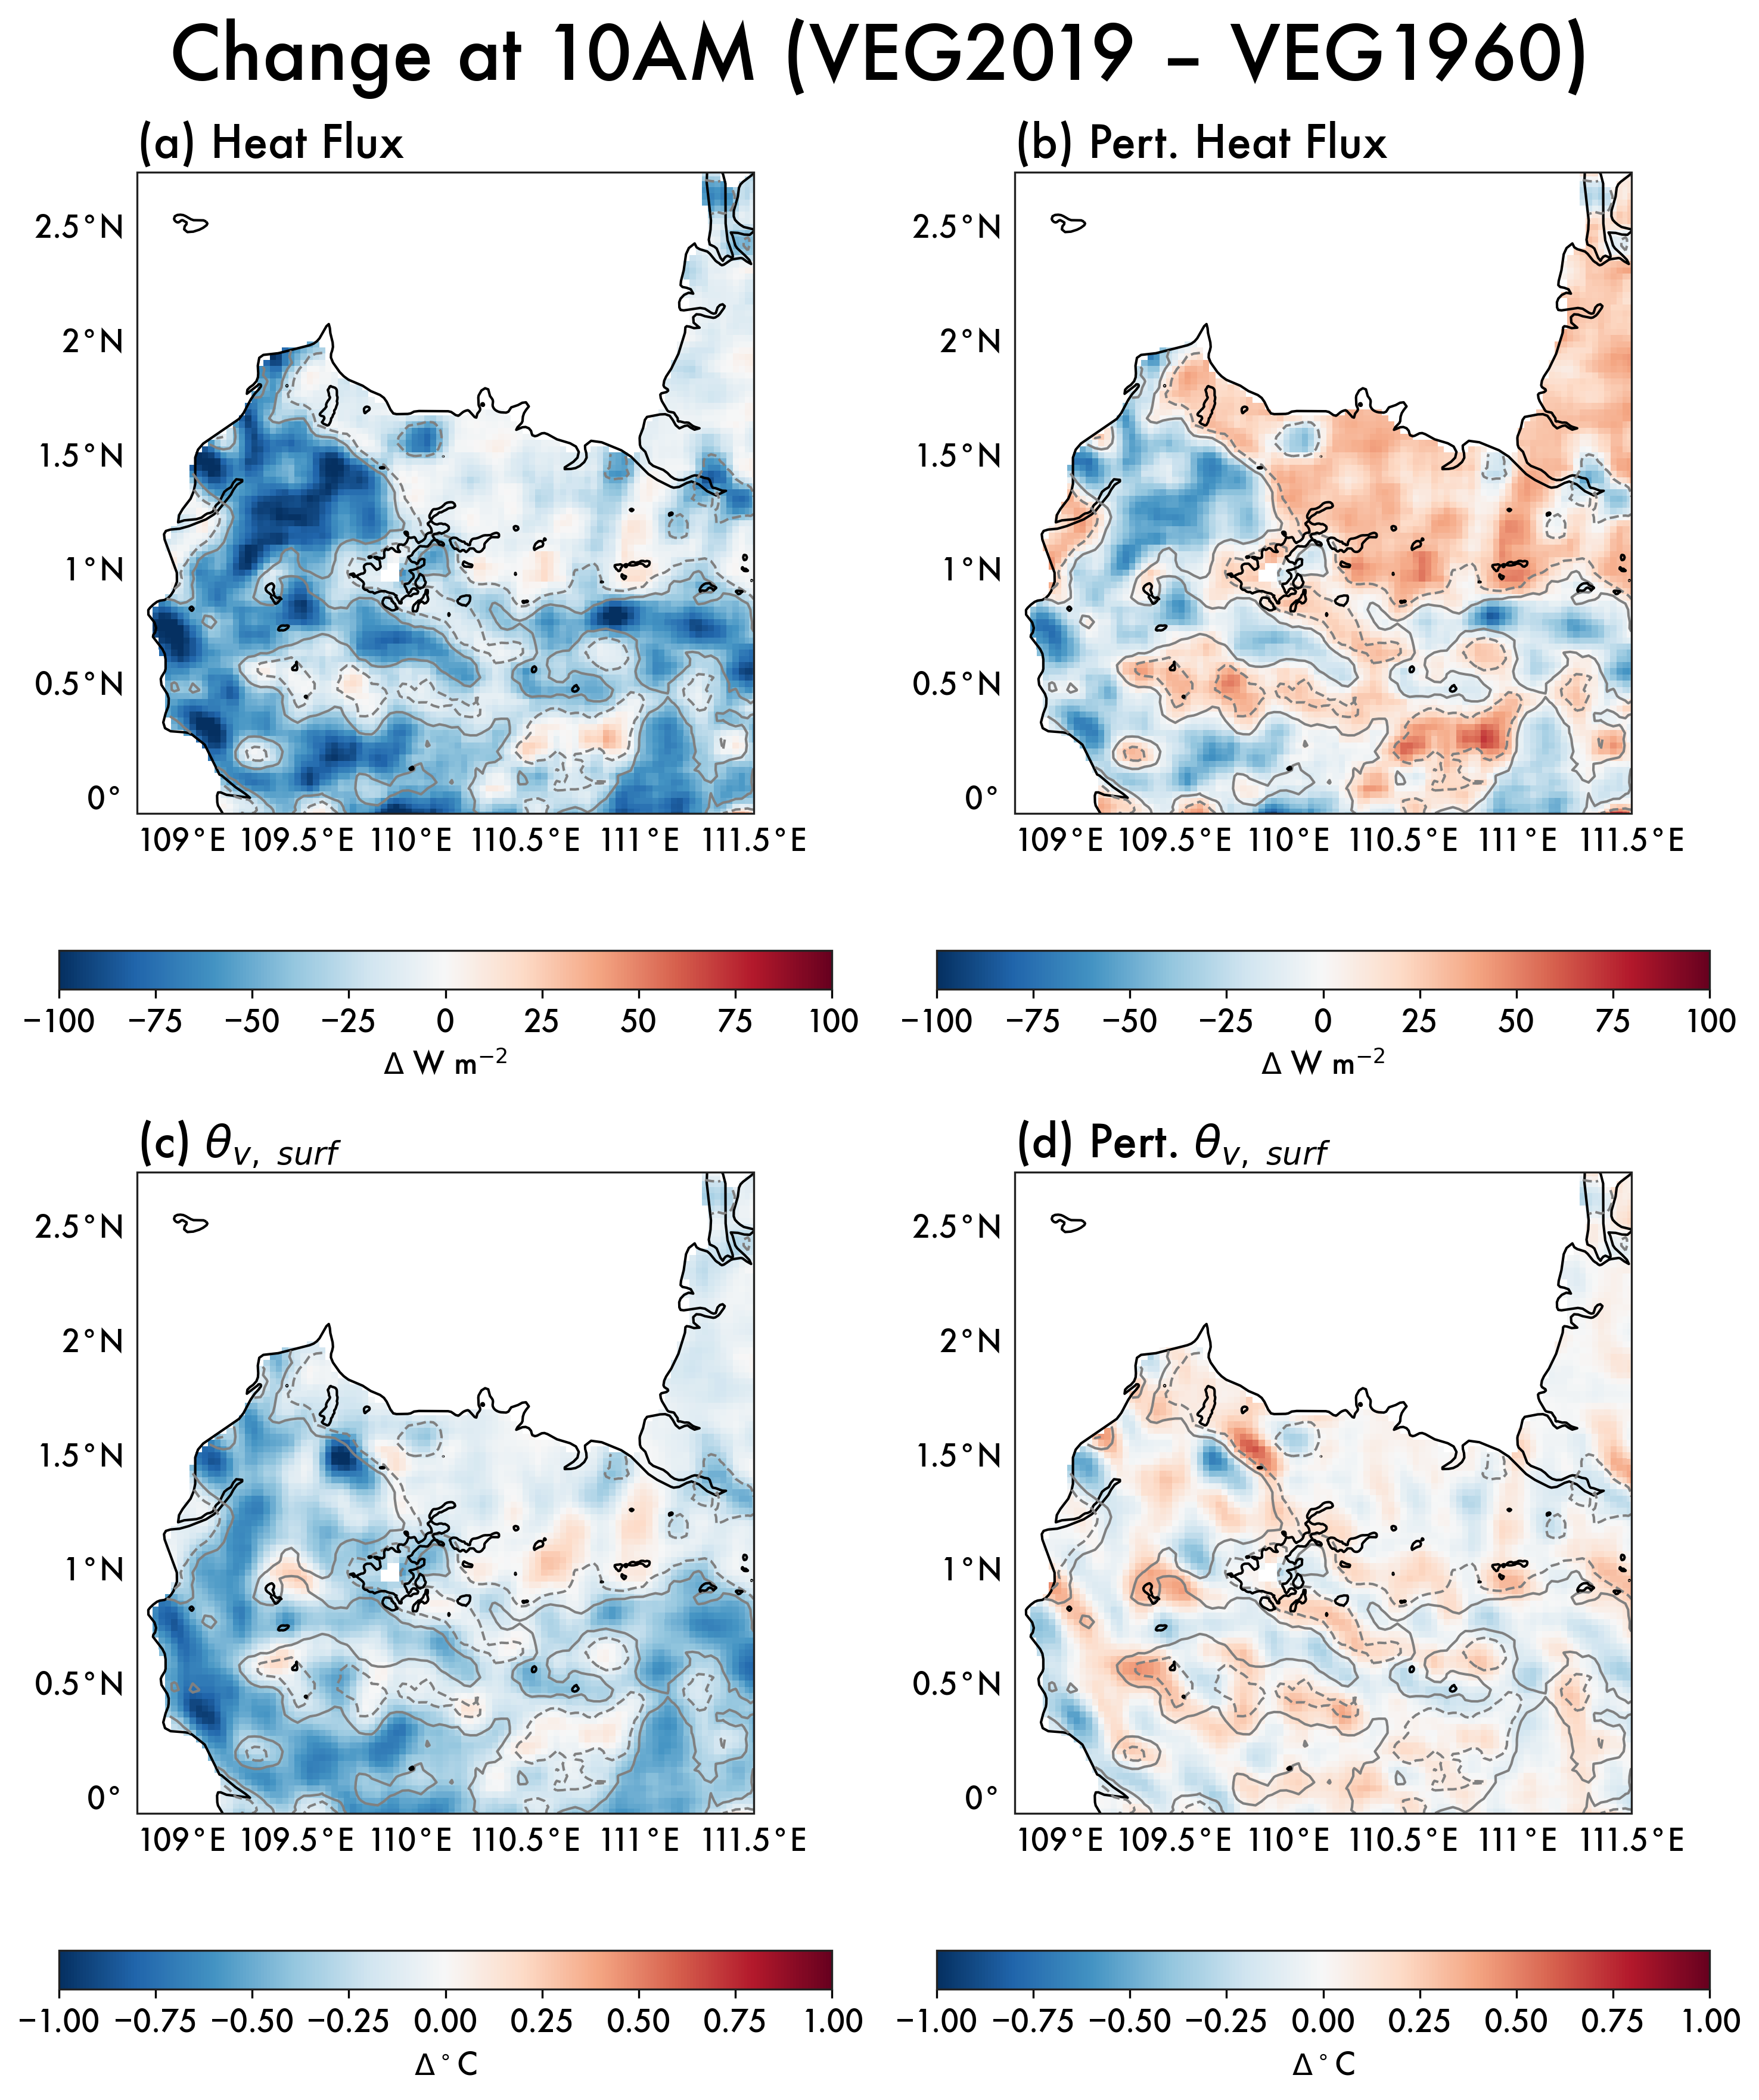

In [139]:
fig, axes = plt.subplots(
    2, 2, figsize=(10, 12), subplot_kw={"projection": ccrs.PlateCarree()}
)


plt.suptitle("Change at 10AM (VEG2019 – VEG1960)", fontsize=30)

for ax, plot, title in zip(
    axes.flatten(),
    [
        diff.hf,
        diff.hf_pert,
        diff.thetav,
        diff.thetav_pert,
    ],
    [
        "(a) Heat Flux ",
        "(b) Pert. Heat Flux ",
        "(c) $\\theta_{v,\ surf}$",
        "(d) Pert. $\\theta_{v,\ surf}$",
    ],
):
    ax.set_title(title)

    plot = (
        smooth_data_plotting(plot, coarseres, rollres, min_periods=10)
        .where(land > 0.5)
        .compute()
    )

    if "Heat Flux" in title:
        vmin = -100
        vmax = 100
        label = "$\Delta$ W m$^{-2}$"
    else:
        vmin = -1
        vmax = 1
        label = "$\Delta ^\circ$C"

    c = ax.pcolormesh(
        lons,
        lats,
        plot,
        cmap="RdBu_r",
        norm=mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
    )

    plt.colorbar(c, ax=ax, orientation="horizontal", label=label)
    ax.contour(
        lons,
        lats,
        forest,
        levels=[-0.5, -0.25],
        colors=["gray", "gray"],
        linestyles=["-", "--"],
        linewidths=[1, 1],
    )

    ax.coastlines()
    add_latlon(ax)
    add_topography(ax, topo, lcol="black")

    ax.set_xlim(lons.min(), lons.max())
    ax.set_ylim(lats.min(), lats.max())

plt.tight_layout()

plt.savefig(f"{figPath}/fig8_mesoscale_circulation.pdf")
plt.show()
plt.close("all")

# Figure 9: moisture convergence

This script uses output from "calculate_dist_coast.py" to show impacts of deforestation on sea breeze and associated cloud formation.

In [34]:
# Read in low-level moisture flux convergence
past_mfc = xr.open_dataset(
    (f"/squall/gleung/borneolcc-analysis/paper-analysis/llmfc-diurnal-lc1960.h5")
).MFC.sel(hour_day=slice(10, 19), dist_coast_bins=slice(0, 50))
pres_mfc = xr.open_dataset(
    (f"/squall/gleung/borneolcc-analysis/paper-analysis/llmfc-diurnal-lc2019.h5")
).MFC.sel(hour_day=slice(10, 19), dist_coast_bins=slice(0, 50))

# Read in cloud fraction
past_cf = xr.open_dataset(
    (f"/squall/gleung/borneolcc-analysis/paper-analysis/cldfrac-diurnal-lc1960.h5")
).segmentation_mask.sel(hour_day=slice(10, 19), dist_coast_bins=slice(0, 50))
pres_cf = xr.open_dataset(
    (f"/squall/gleung/borneolcc-analysis/paper-analysis/cldfrac-diurnal-lc2019.h5")
).segmentation_mask.sel(hour_day=slice(10, 19), dist_coast_bins=slice(0, 50))

In [35]:
from scipy.signal import find_peaks

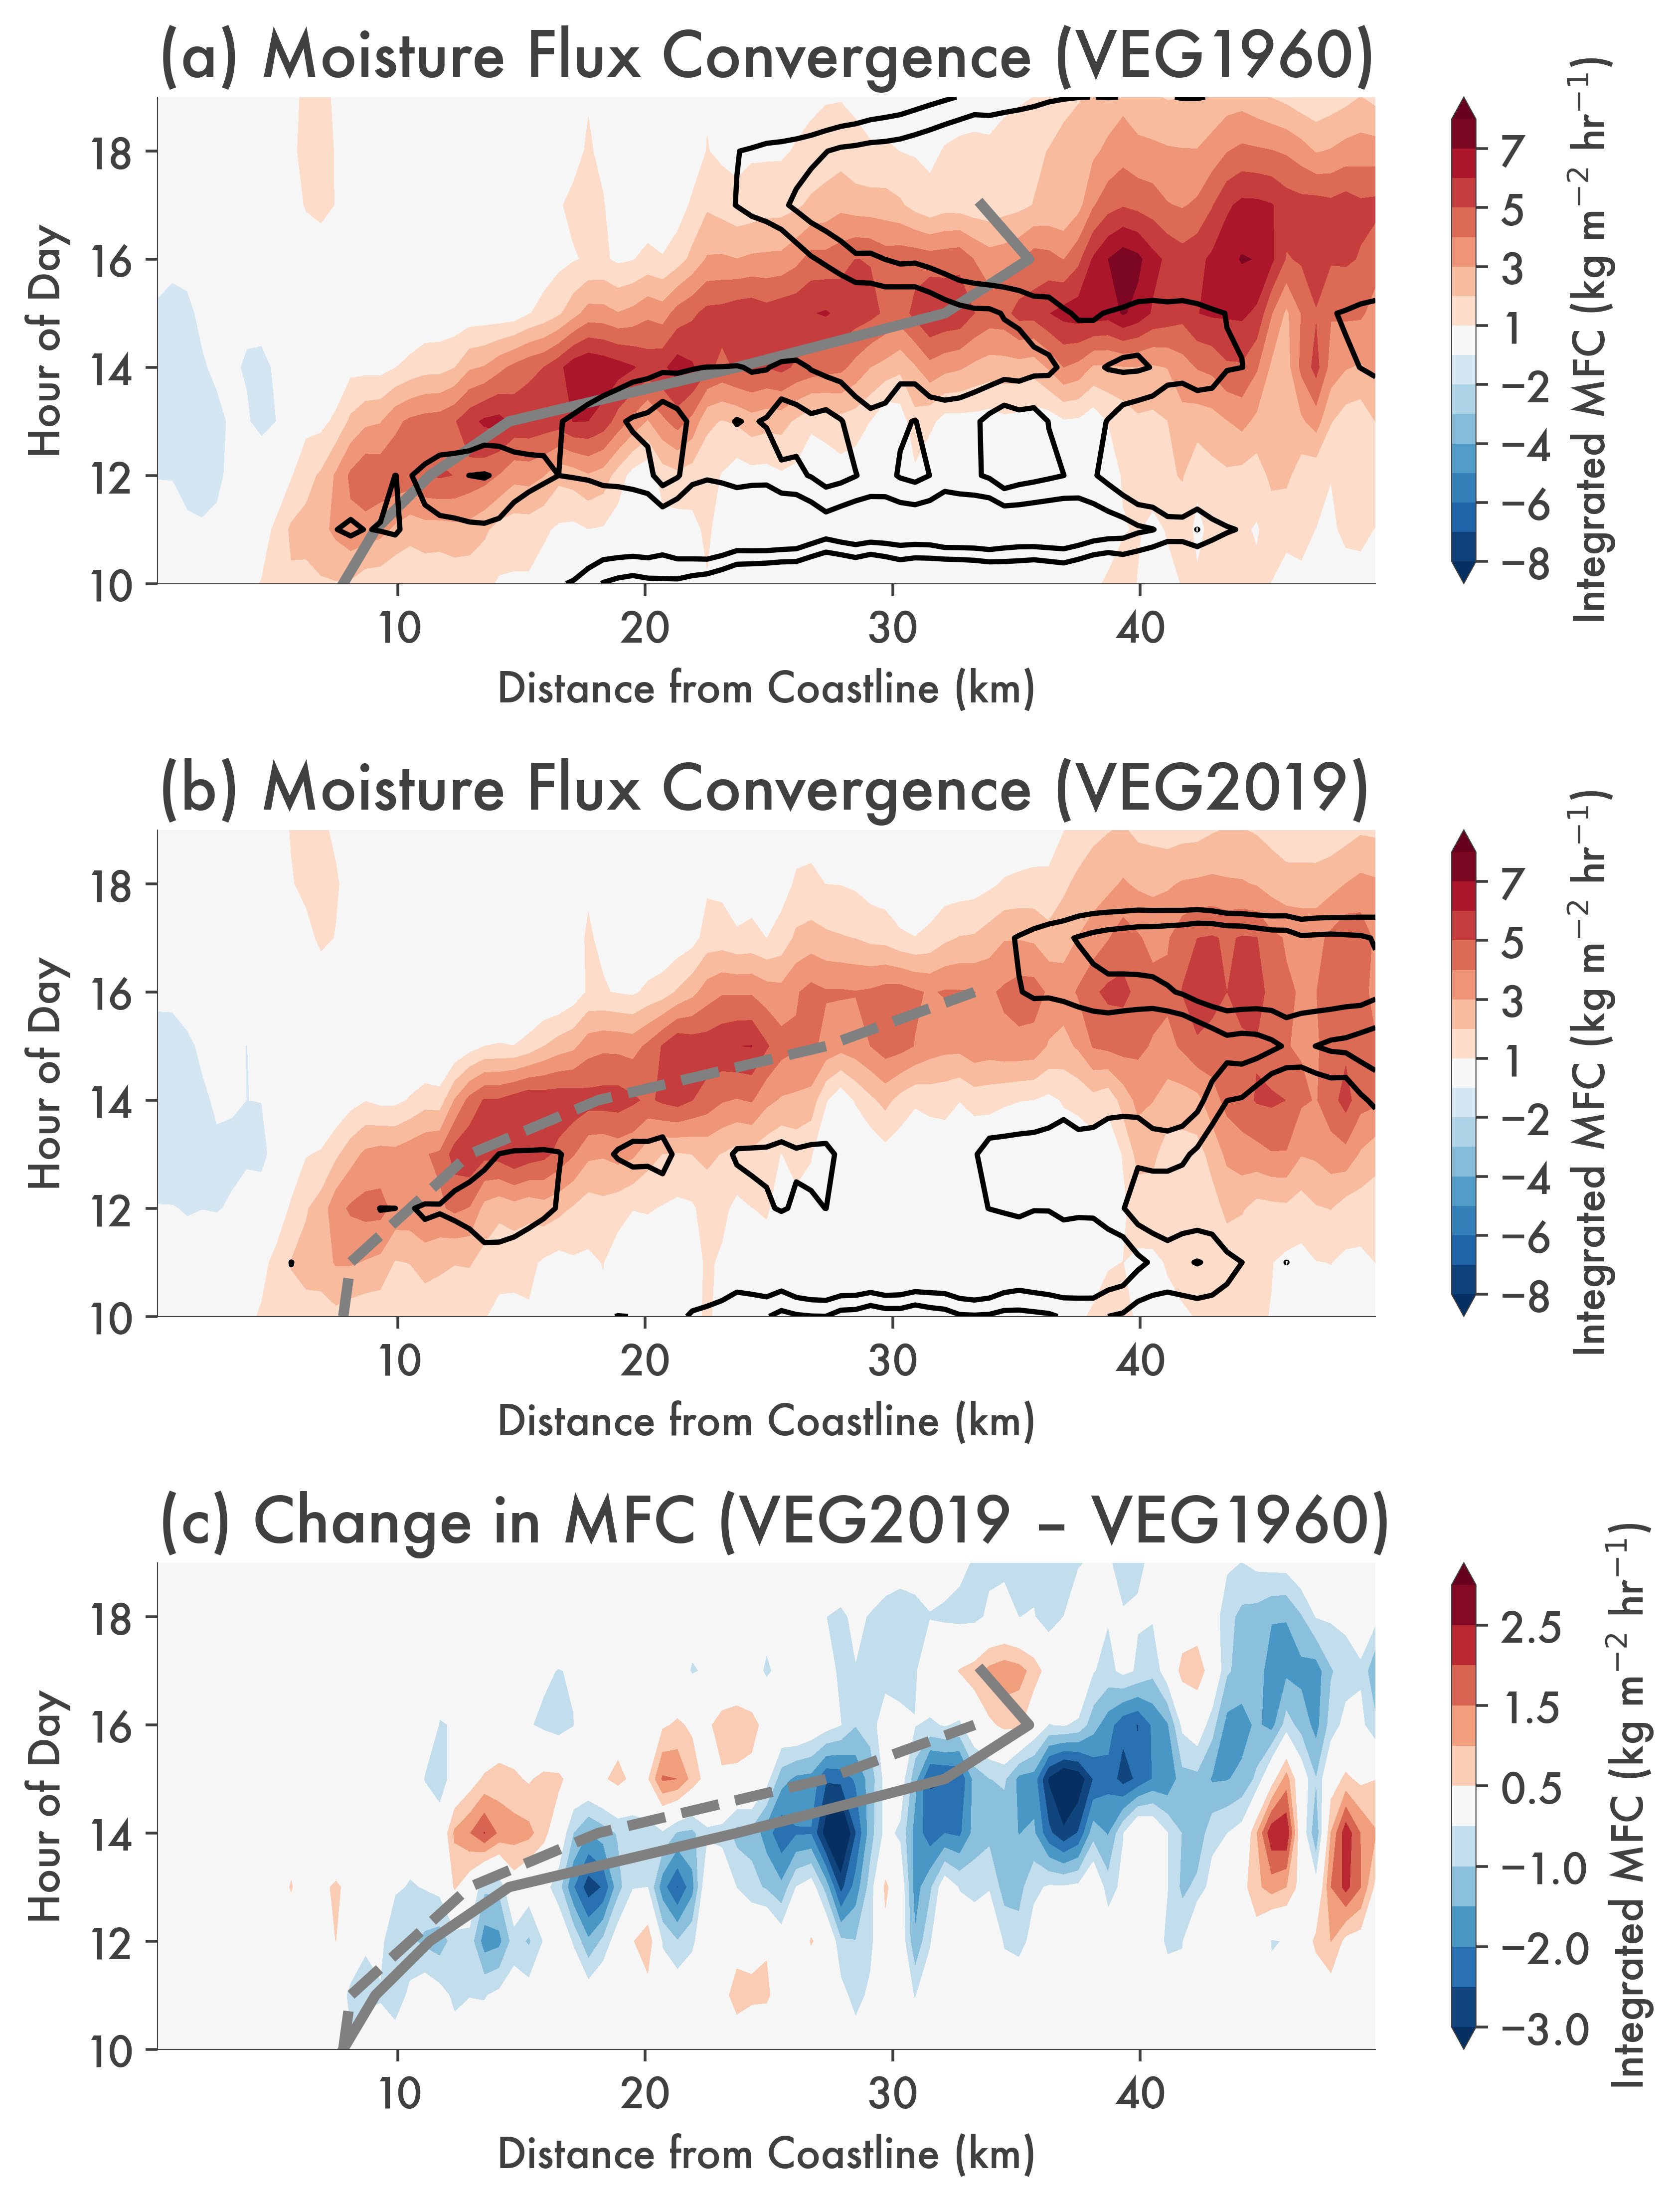

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(7, 9))

for ax, plot, title, levels, ls in zip(
    axes,
    [past_mfc, pres_mfc, pres_mfc - past_mfc],
    [
        "(a) Moisture Flux Convergence (VEG1960)",
        "(b) Moisture Flux Convergence (VEG2019)",
        "(c) Change in MFC (VEG2019 – VEG1960)",
    ],
    [
        [-8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8],
        [-8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8],
        [-3, -2.5, -2, -1.5, -1, -0.5, 0.5, 1, 1.5, 2, 2.5, 3],
    ],
    ["-", "--", ""],
):
    c = ax.contourf(
        plot.dist_coast_bins,
        plot.hour_day,
        3600 * plot,  # convert to units of kg/m2 hr rather than kg/m2 s
        cmap="RdBu_r",
        norm=mcolors.TwoSlopeNorm(vcenter=0),
        levels=levels,
        extend="both",
    )

    plt.colorbar(c, ax=ax, label="Integrated MFC (kg m$^{-2}$ hr$^{-1}$)")

    ax.set_title(title)
    ax.set_xlabel("Distance from Coastline (km)")
    ax.set_ylabel("Hour of Day")

    # also want to define the sea breeze front
    # here we define sea breeze front as the peak in moisture flux convergence
    # (using scipy peak finding) at a given time of day
    # we smooth the sea breeze front slightly using a rolling mean for smoother plotting
    fnts = []
    for h in plot.hour_day:
        x = plot.sel(hour_day=h) * 3600
        pks = find_peaks(x, prominence=[1.5])

        prom = pks[1].get("prominences")
        pks = pks[0]

        if len(pks) > 0:
            pks = plot.dist_coast_bins.values[pks[prom.argmax()]]
        else:
            pks = np.nan

        fnts.append(pks)

    ax.plot(
        pd.Series(fnts).rolling(3, center=True, min_periods=2).mean(),
        plot.hour_day,
        ls=ls,
        lw=3,
        color="gray",
    )

    # also plot both sea breeze front locations on the difference plot
    axes[-1].plot(
        pd.Series(fnts).rolling(3, center=True, min_periods=2).mean(),
        plot.hour_day,
        ls=ls,
        lw=3,
        color="gray",
    )

# plot cloud fraction contours
for plot, ax in zip([past_cf, pres_cf], axes[:-1]):
    ax.contour(
        plot.dist_coast_bins,
        plot.hour_day,
        plot,
        levels=[0.035, 0.04],
        linewidths=1.5,
        colors="black",
    )

plt.tight_layout()

# save figure
plt.savefig(f"{figPath}/fig9_seabreeze_mfc.pdf")
plt.show()
plt.close("all")

# Figure 11: Diurnal cycle of raining clouds

Same as Figure 5 but only for raining clouds

## Preliminary calculations

In [475]:
# define the x and y bins
cells_past = pd.read_parquet(
    f"/squall/gleung/borneolcc-analysis/tobac/lc1960_rte/qc_final_cloudy_updrafts.pq"
)
cells_pres = pd.read_parquet(
    f"/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/qc_final_cloudy_updrafts.pq"
)

thresh = 0
cells_past = cells_past[cells_past.pcp_mean > thresh]
cells_pres = cells_pres[cells_pres.pcp_mean > thresh]

In [ ]:
X = np.tile(np.linspace(0, 24, 49), (21, 1)).T  # hour of day in 0.5 hr increments
Y = np.tile(
    alt[1::5] / 1000, (49, 1)
)  # cloud top height every 5 altitude bins# Now we calculate PDF for past and present cloudy number and cloudy area.

# Everything is divided by 3 because there are three days in our simulation (so this gives units
# of e.g., # cells hour^-1 km^-1).
n_past = (
    kde_2d(
        cells_past[["CTH", "hour_day"]],
        xvar="hour_day",
        xbins=X,
        yvar="CTH",
        ybins=Y,
        mult=len(cells_past),
    )
    / 3
)

n_pres = (
    kde_2d(
        cells_pres[["CTH", "hour_day"]],
        xvar="hour_day",
        xbins=X,
        yvar="CTH",
        ybins=Y,
        mult=len(cells_pres),
    )
    / 3
)


# These are weighted by the raining amount so that the PDF integrates to the total rain in kg
p_past = (
    kde_2d(
        cells_past[["CTH", "hour_day"]],
        xvar="hour_day",
        xbins=X,
        yvar="CTH",
        ybins=Y,
        mult=(5 / 60) * cells_past.pcp_total.sum(),
        weights=cells_past.pcp_total.fillna(0) / cells_past.pcp_total.sum(),
    )
    / 3
)

p_pres = (
    kde_2d(
        cells_pres[["CTH", "hour_day"]],
        xvar="hour_day",
        xbins=X,
        yvar="CTH",
        ybins=Y,
        mult=(5 / 60) * cells_pres.pcp_total.sum(),
        weights=cells_pres.pcp_total.fillna(0) / cells_pres.pcp_total.sum(),
    )
    / 3
)

In [477]:
n_mag = {
    "cmap": "viridis",
    "norm": None,
    "levels": np.linspace(0, 80, 17),
    "extend": "max",
    "label": "#",
}

n_diff = {
    "cmap": "RdBu_r",
    "norm": mcolors.TwoSlopeNorm(vcenter=0),
    "levels": [-20, -15, -10, -5, 5, 10, 15, 20],
    "extend": "both",
    "label": "$\Delta$#",
}

p_mag = {
    "cmap": "viridis",
    "norm": None,
    "levels": np.linspace(0, 400, 17),
    "extend": "max",
    "label": "kg",
}

p_diff = {
    "cmap": "RdBu_r",
    "norm": mcolors.TwoSlopeNorm(vcenter=0),
    "levels": [
        -100,
        -80,
        -60,
        -40,
        -20,
        20,
        40,
        60,
        80,
        100,
    ],
    "extend": "both",
    "label": "$\Delta$kg",
}

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:41: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1406094/1417598667.py:14: SyntaxWarning: invalid escape sequence '\D'
  "label": "$\Delta$#",
/tmp/ipykernel_1406094/1417598667.py:41: SyntaxWarning: invalid escape sequence '\D'
  "label": "$\Delta$kg",


## Actual plots

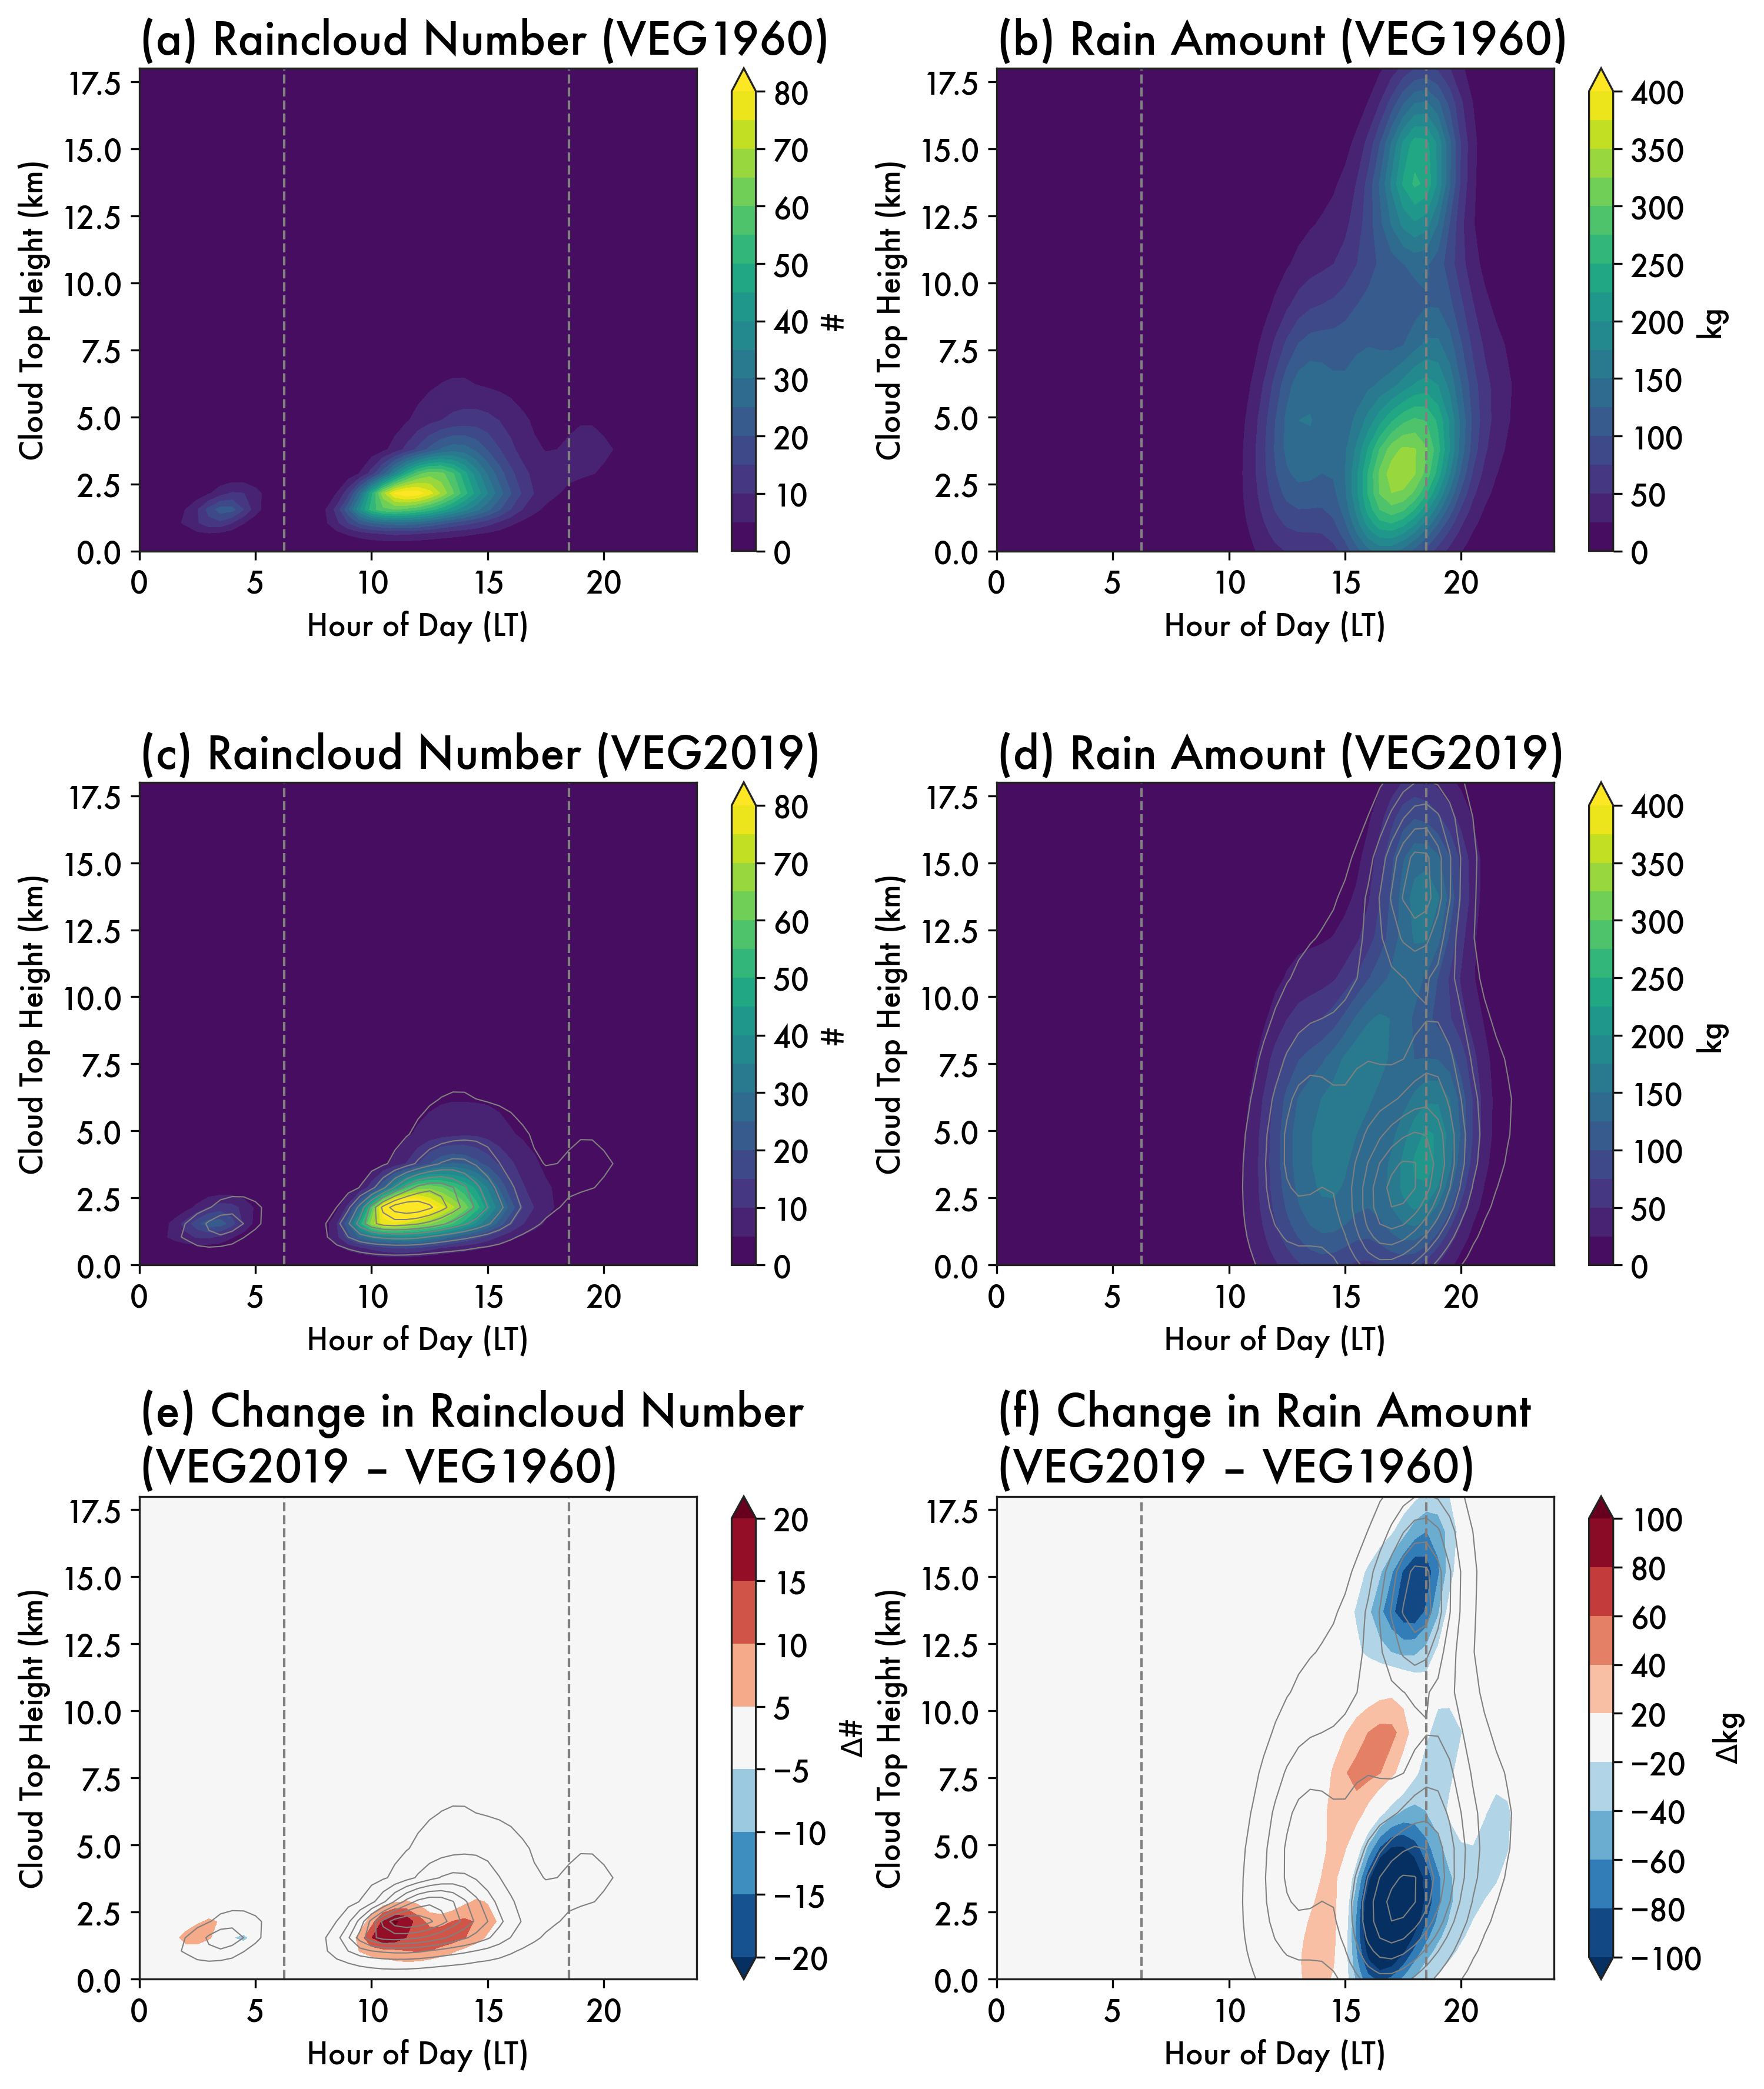

In [473]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

# plotting main filled contours
for ax, data, params in zip(
    axes.T.flatten(),
    [n_past, n_pres, n_pres - n_past, p_past, p_pres, p_pres - p_past],
    [n_mag, n_mag, n_diff, p_mag, p_mag, p_diff],
):

    c = ax.contourf(
        data.columns,
        data.index,
        data,
        cmap=params.get("cmap"),
        norm=params.get("norm"),
        levels=params.get("levels"),
        extend=params.get("extend"),
    )

    plt.colorbar(c, ax=ax, label=params.get("label"))


# plotting the number/area contours for VEG1960 simulation as reference on other panels
for axs, data, params in zip(
    [axes.T[0][1:], axes.T[1][1:]], [n_past, p_past], [n_mag, p_mag]
):
    for ax in axs:
        ax.contour(
            data.columns,
            data.index,
            data.values,
            colors="gray",
            levels=params.get("levels")[1::2],
            linewidths=0.5,
        )


# ancilliary plotting: figure labels, etc.
for ax, title in zip(
    axes.flatten(),
    [
        "(a) Raincloud Number (VEG1960)",
        "(b) Rain Amount (VEG1960)",
        "(c) Raincloud Number (VEG2019)",
        "(d) Rain Amount (VEG2019)",
        "(e) Change in Raincloud Number\n(VEG2019 – VEG1960)",
        "(f) Change in Rain Amount\n(VEG2019 – VEG1960)",
    ],
):
    ax.set_title(title)
    ax.set_ylabel("Cloud Top Height (km)")
    ax.set_xlabel("Hour of Day (LT)")

    ax.axvline(6.25, ls="--", color="gray", lw=1)
    ax.axvline(18.5, ls="--", color="gray", lw=1)
    ax.set_ylim(0, 18)

plt.tight_layout()

# save figure
plt.savefig(f"{figPath}/fig11_diurnal_raining_clouds_6panel.pdf")
plt.show()
plt.close("all")

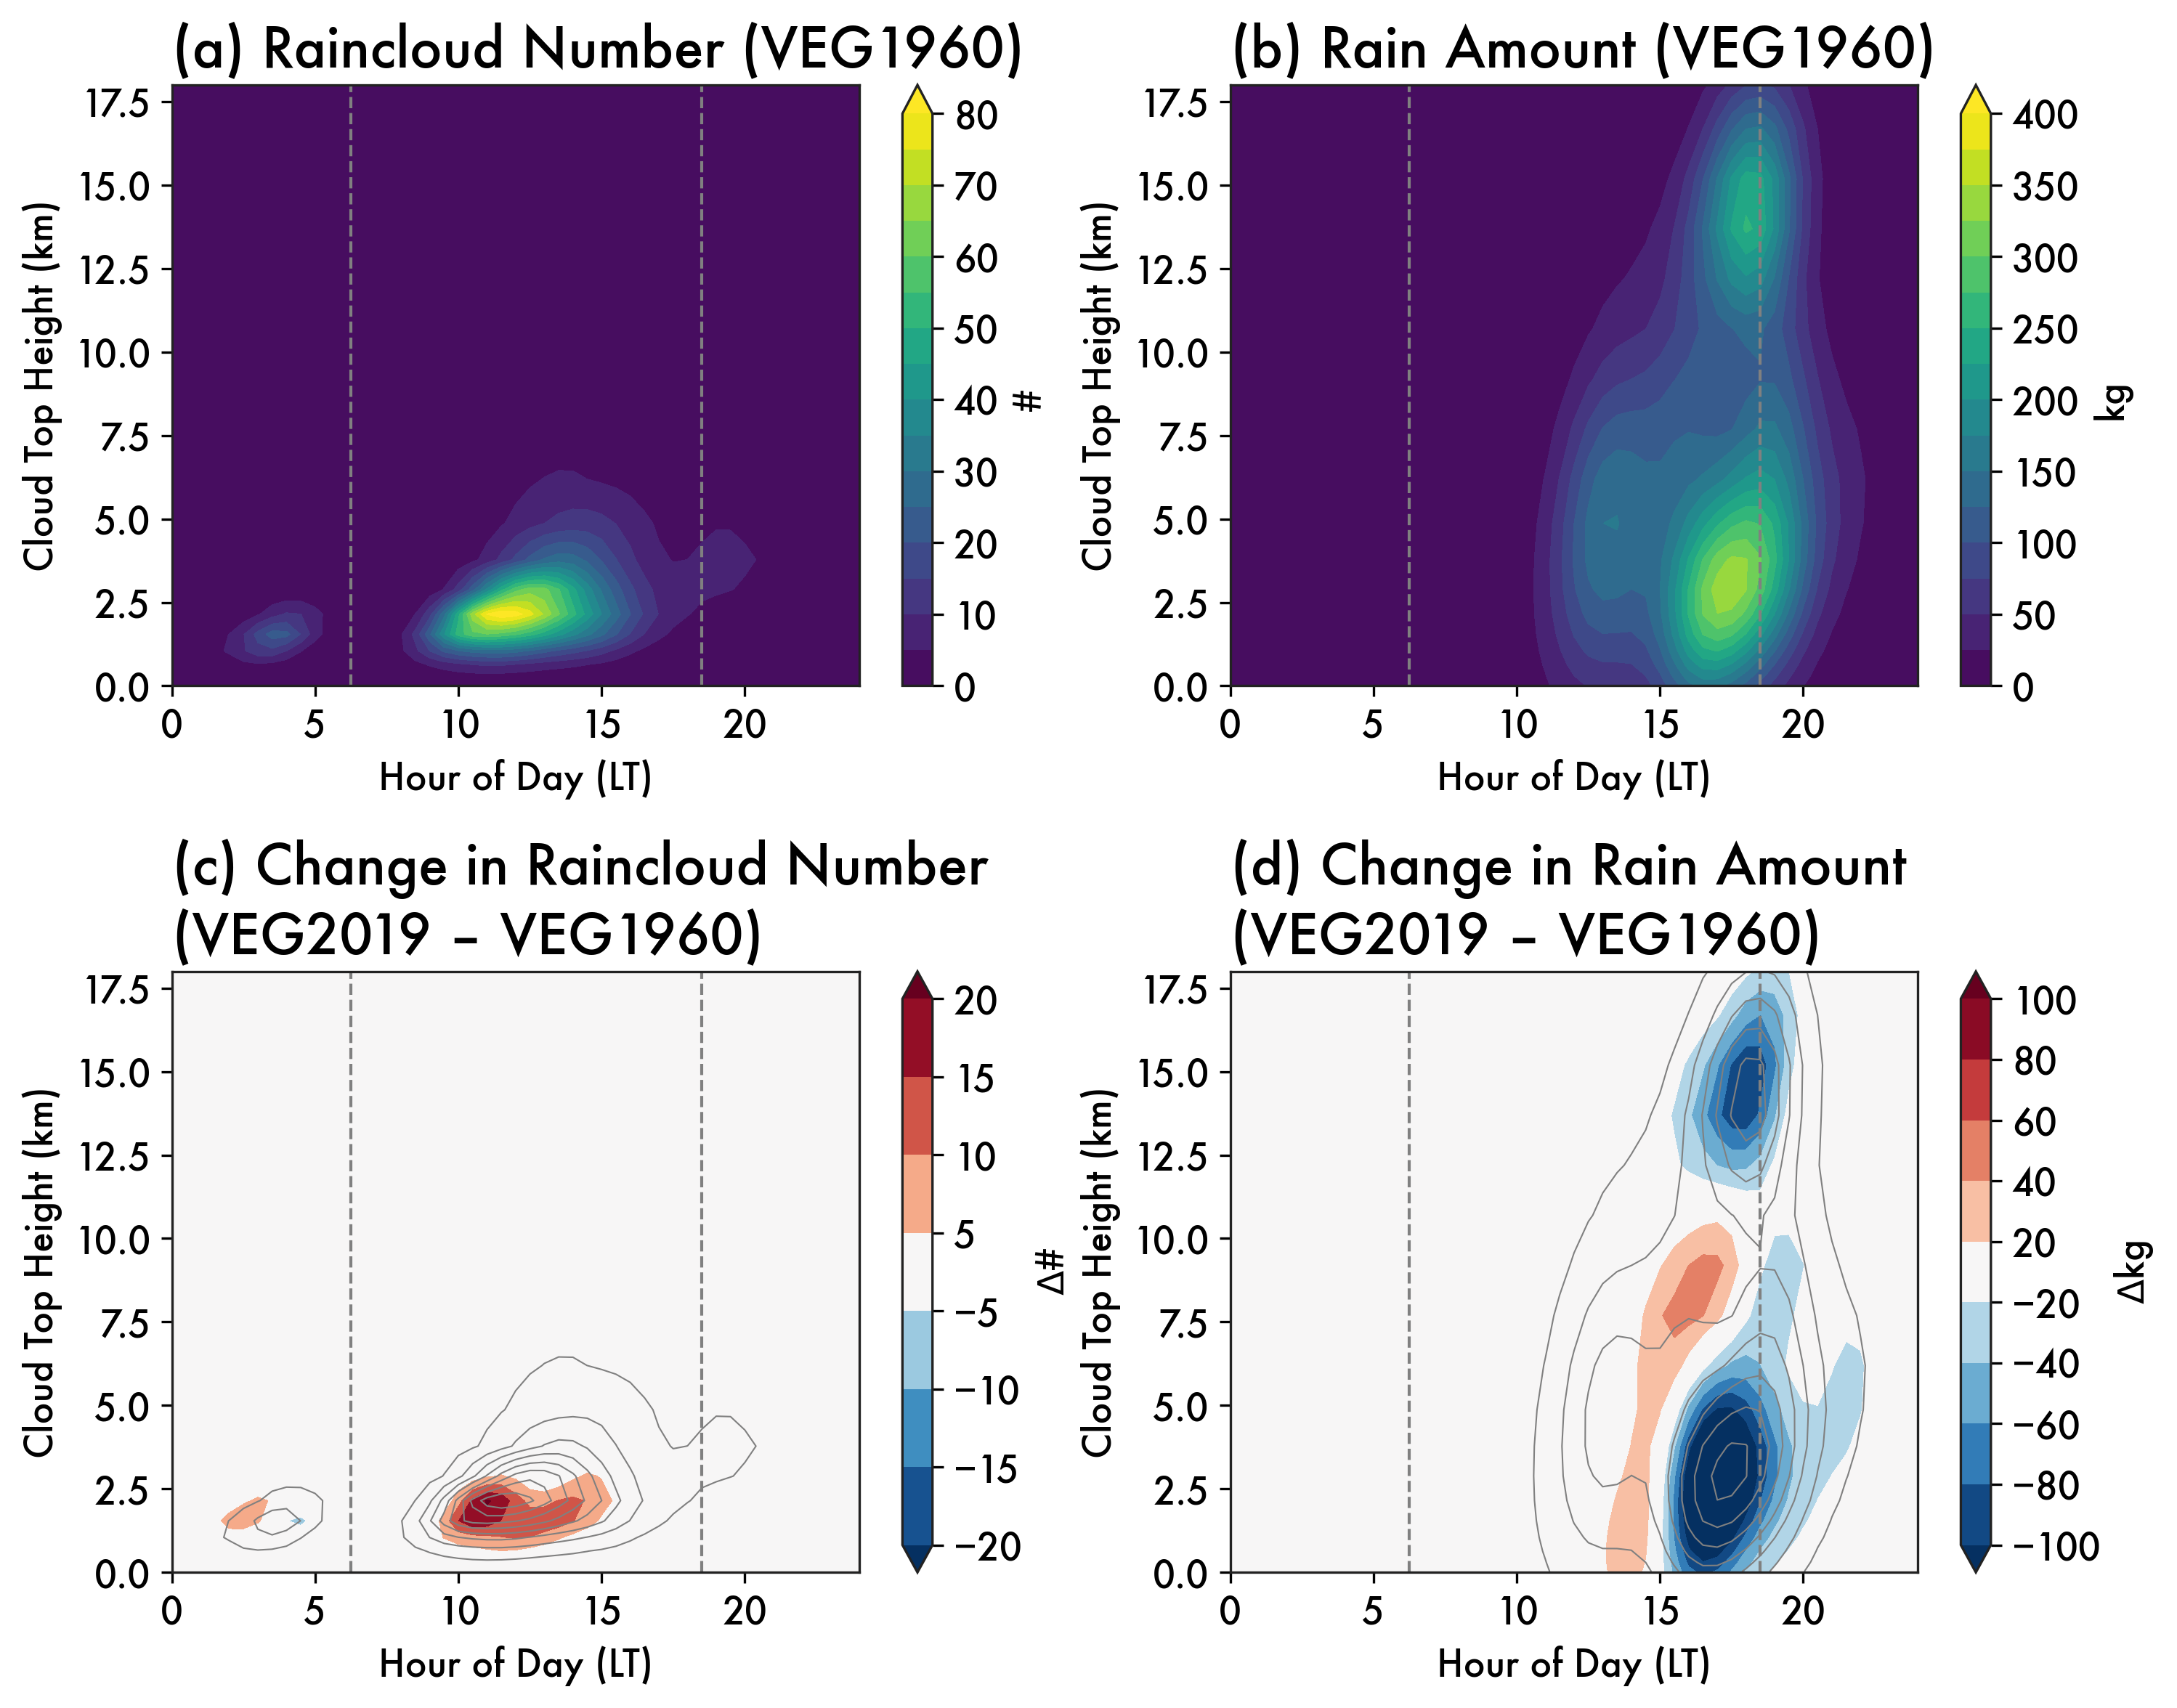

In [474]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# plotting main filled contours
for ax, data, params in zip(
    axes.T.flatten(),
    [n_past, n_pres - n_past, p_past, p_pres - p_past],
    [n_mag, n_diff, p_mag, p_diff],
):

    c = ax.contourf(
        data.columns,
        data.index,
        data,
        cmap=params.get("cmap"),
        norm=params.get("norm"),
        levels=params.get("levels"),
        extend=params.get("extend"),
    )

    plt.colorbar(c, ax=ax, label=params.get("label"))


# plotting the number/area contours for VEG1960 simulation as reference on other panels
for axs, data, params in zip(
    [axes.T[0][1:], axes.T[1][1:]], [n_past, p_past], [n_mag, p_mag]
):
    for ax in axs:
        ax.contour(
            data.columns,
            data.index,
            data.values,
            colors="gray",
            levels=params.get("levels")[1::2],
            linewidths=0.5,
        )


# ancilliary plotting: figure labels, etc.
for ax, title in zip(
    axes.flatten(),
    [
        "(a) Raincloud Number (VEG1960)",
        "(b) Rain Amount (VEG1960)",
        "(c) Change in Raincloud Number\n(VEG2019 – VEG1960)",
        "(d) Change in Rain Amount\n(VEG2019 – VEG1960)",
    ],
):
    ax.set_title(title)
    ax.set_ylabel("Cloud Top Height (km)")
    ax.set_xlabel("Hour of Day (LT)")

    ax.axvline(6.25, ls="--", color="gray", lw=1)
    ax.axvline(18.5, ls="--", color="gray", lw=1)
    ax.set_ylim(0, 18)

plt.tight_layout()

# save figure
plt.savefig(f"{figPath}/fig11_diurnal_raining_clouds_4panel.pdf")
plt.show()
plt.close("all")